In [4]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

# Set English style
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
sns.set_palette("husl")

## 1. Load All TOFU_SUMMARY.json Files

In [5]:
def parse_model_name(dirname):
    """Parse model directory name and extract key information"""
    parts = {}
    
    # Extract model name
    if 'Llama-2-7b' in dirname:
        parts['model'] = 'Llama-2-7B'
    elif 'Llama-3.2-1B' in dirname:
        parts['model'] = 'Llama-3.2-1B'
    elif 'phi-1_5' in dirname:
        parts['model'] = 'Phi-1.5'
    else:
        parts['model'] = 'Unknown'
    
    # Extract forget set
    if 'forget05' in dirname:
        parts['forget_set'] = 'forget05'
    elif 'forget10' in dirname:
        parts['forget_set'] = 'forget10'
    else:
        parts['forget_set'] = 'unknown'
    
    # Extract method
    if 'GradAscent' in dirname:
        parts['method'] = 'GradAscent'
    elif 'GradDiff' in dirname:
        parts['method'] = 'GradDiff'
    elif 'SimNPO' in dirname:
        parts['method'] = 'SimNPO'
    elif 'NPO' in dirname:
        parts['method'] = 'NPO'
    else:
        parts['method'] = 'Unknown'
    
    # Extract hyperparameters
    beta_match = re.search(r'beta([0-9.]+)', dirname)
    if beta_match:
        parts['beta'] = float(beta_match.group(1))
    
    gamma_match = re.search(r'gamma([0-9.]+)', dirname)
    if gamma_match:
        parts['gamma'] = float(gamma_match.group(1))
    
    alpha_match = re.search(r'alpha([0-9.]+)', dirname)
    if alpha_match:
        parts['alpha'] = float(alpha_match.group(1))
    
    lr_match = re.search(r'lr([0-9e-]+)', dirname)
    if lr_match:
        parts['lr'] = lr_match.group(1)
    
    # Extract epoch
    epoch_match = re.search(r'epoch(\d+)', dirname)
    if epoch_match:
        parts['epoch'] = int(epoch_match.group(1))
    
    return parts

def load_all_summaries(base_path):
    """Load all TOFU_SUMMARY.json files"""
    results = []
    base_path = Path(base_path)
    
    for model_dir in base_path.iterdir():
        if not model_dir.is_dir():
            continue
            
        summary_file = model_dir / 'evals' / 'TOFU_SUMMARY.json'
        if not summary_file.exists():
            continue
        
        try:
            with open(summary_file, 'r') as f:
                data = json.load(f)
            
            # Parse directory name
            parsed = parse_model_name(model_dir.name)
            parsed['dir_name'] = model_dir.name
            
            # Merge data
            parsed.update(data)
            results.append(parsed)
            
        except Exception as e:
            print(f"Error loading {summary_file}: {e}")
    
    return pd.DataFrame(results)

# Load data
# unlearn_path = '/cnz/data/project/my-open-unlearning/saves/unlearn/llama_2_chat'
unlearn_path = '/cnz/data/project/my-open-unlearning/saves/unlearn/phi'
df = load_all_summaries(unlearn_path)

# Filter only one model type
# Uncomment the model you want to analyze:
df = df[df['model'] == 'Phi-1.5'].copy()
# df = df[df['model'] == 'Llama-2-7B'].copy()
# df = df[df['model'] == 'Llama-3.2-1B'].copy()

# Get model name dynamically
model_name = df['model'].iloc[0] if len(df) > 0 else 'Unknown'

print(f"Successfully loaded {len(df)} {model_name} model evaluation results")
print(f"\nMethods: {df['method'].unique()}")
print(f"Forget sets: {df['forget_set'].unique()}")

Successfully loaded 62 Phi-1.5 model evaluation results

Methods: ['NPO' 'SimNPO']
Forget sets: ['forget05' 'forget10']


In [6]:
# View data overview
df.head(10)

,model,forget_set,method,beta,gamma,epoch,dir_name,exact_memorization,extraction_strength,extraction_strength_retain,forget_Q_A_Prob,forget_Q_A_ROUGE,forget_quality,forget_truth_ratio,model_utility,privleak,retain_Q_A_Prob,retain_Q_A_ROUGE
0,Phi-1.5,forget05,NPO,0.10,0.200,5,tofu_phi-1_5_forget05_NPO_beta0.1_gamma0.2_epoch5,0.640783,0.073016,0.217807,0.179333,0.398206,6.801920e-02,0.630110,0.374849,-17.790377,0.529774,0.467698
1,Phi-1.5,forget05,NPO,0.10,0.400,5,tofu_phi-1_5_forget05_NPO_beta0.1_gamma0.4_epoch5,0.631205,0.074977,0.141005,0.151730,0.438961,2.205412e-01,0.649489,0.353433,-21.314741,0.328020,0.482194
2,Phi-1.5,forget05,NPO,0.15,0.300,5,tofu_phi-1_5_forget05_NPO_beta0.15_gamma0.3_ep...,0.676727,0.087244,0.198602,0.244023,0.416399,2.209236e-02,0.616153,0.372929,-42.591174,0.518640,0.472759
3,Phi-1.5,forget05,NPO,0.15,0.500,5,tofu_phi-1_5_forget05_NPO_beta0.15_gamma0.5_ep...,0.660293,0.085014,0.151394,0.211263,0.423889,5.213909e-02,0.632896,0.358874,-42.399632,0.393271,0.466700
4,Phi-1.5,forget05,SimNPO,2.00,0.200,5,tofu_phi-1_5_forget05_SimNPO_beta2.0_gamma0.2_...,0.787040,0.135906,0.538316,0.364482,0.449440,8.114130e-08,0.507640,0.396035,-84.155685,0.794398,0.556304
5,Phi-1.5,forget05,SimNPO,2.25,0.200,5,tofu_phi-1_5_forget05_SimNPO_beta2.25_gamma0.2...,0.794038,0.142910,0.544171,0.387907,0.452560,3.602473e-09,0.504619,0.399019,-87.281643,0.796228,0.551950
6,Phi-1.5,forget05,SimNPO,2.25,0.175,5,tofu_phi-1_5_forget05_SimNPO_beta2.25_gamma0.1...,0.806836,0.158163,0.541019,0.425988,0.456919,3.602473e-09,0.499647,0.397574,-90.373123,0.797179,0.553665
7,Phi-1.5,forget10,NPO,0.20,0.300,5,tofu_phi-1_5_forget10_NPO_beta0.2_gamma0.3_epoch5,0.748577,0.106652,0.339944,0.344533,0.439989,9.074892e-08,0.561856,0.385507,-77.891487,0.680404,0.522551
8,Phi-1.5,forget10,NPO,0.20,0.500,5,tofu_phi-1_5_forget10_NPO_beta0.2_gamma0.5_epoch5,0.736959,0.107003,0.231257,0.348014,0.440894,6.784754e-07,0.574394,0.383426,-79.548537,0.570768,0.492902
9,Phi-1.5,forget10,SimNPO,2.00,0.100,5,tofu_phi-1_5_forget10_SimNPO_beta2.0_gamma0.1_...,0.836658,0.161636,0.494038,0.545659,0.457639,1.022998e-13,0.513258,0.398040,-96.294159,0.781492,0.553121


## 2. Data Statistics

In [7]:
# Count experiments per method
method_counts = df.groupby(['method', 'forget_set']).size().reset_index(name='count')
print("Number of experiments per configuration:")
print(method_counts.sort_values('count', ascending=False))

Number of experiments per configuration:
   method forget_set  count
0     NPO   forget05     16
1     NPO   forget10     16
2  SimNPO   forget05     15
3  SimNPO   forget10     15


## 3. Core Metrics Visualization

Plot 7 key metrics:
- exact_memorization (EM) - Lower is better
- extraction_strength (ES) - Lower is better
- extraction_strength_retain (ES_Retain) - Higher is better
- forget_quality (FQ) - Higher is better
- model_utility (MU) - Higher is better
- retain_Q_A_ROUGE (Retain ROUGE) - Higher is better
- forget_Q_A_ROUGE (Forget ROUGE) - Lower is better

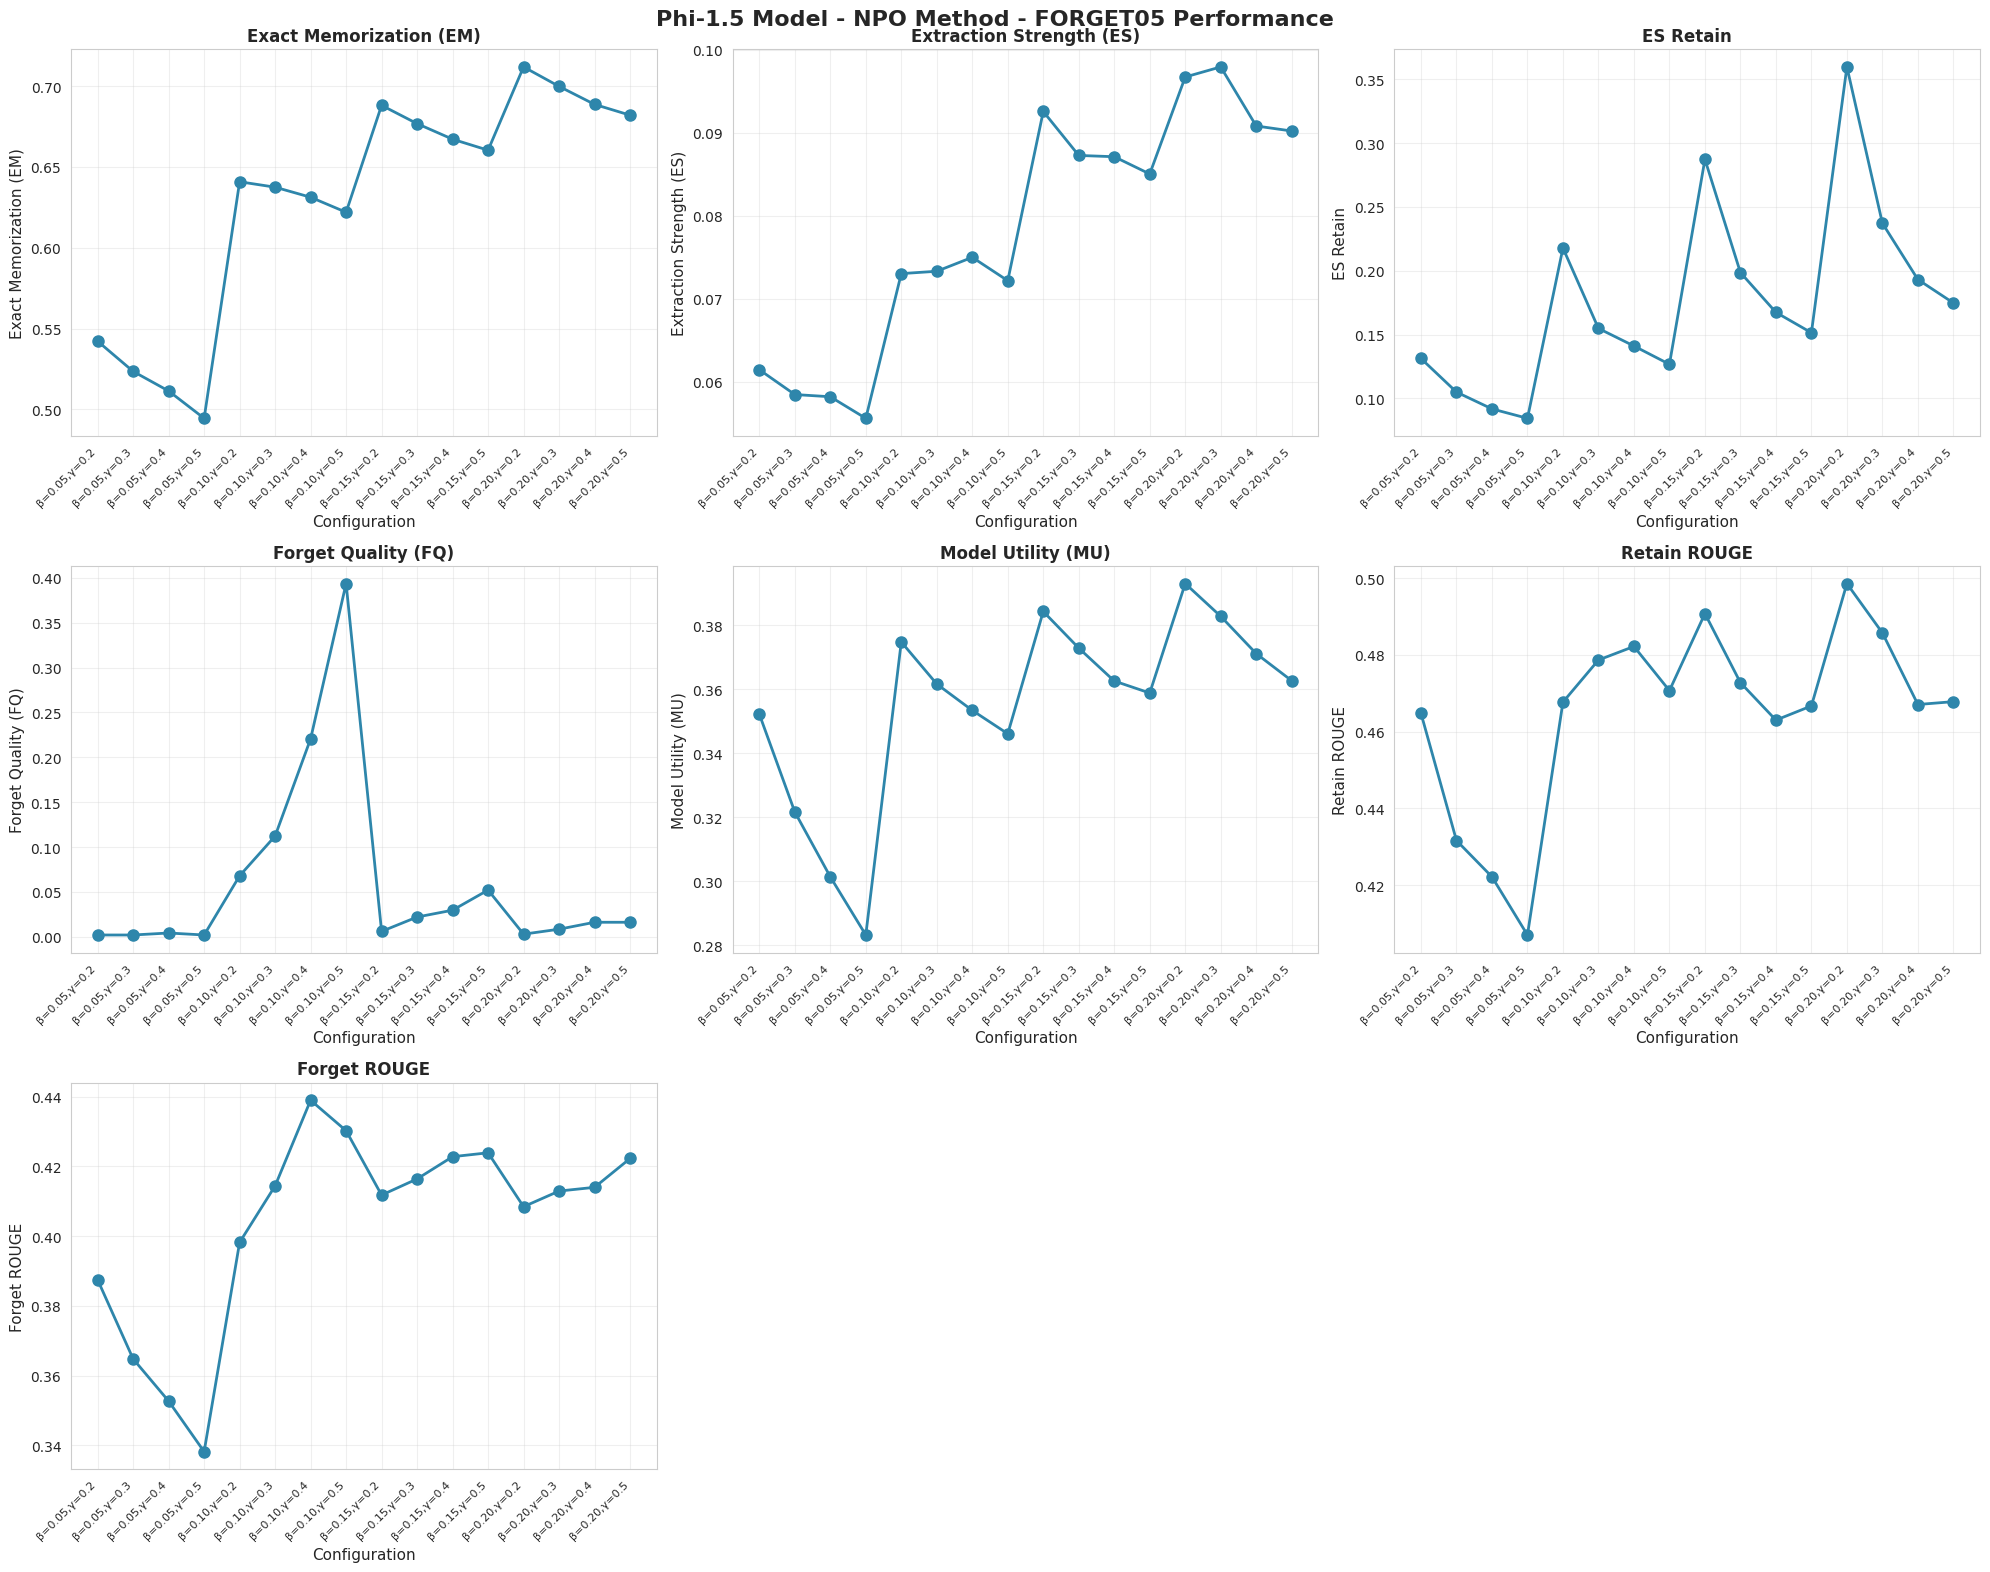

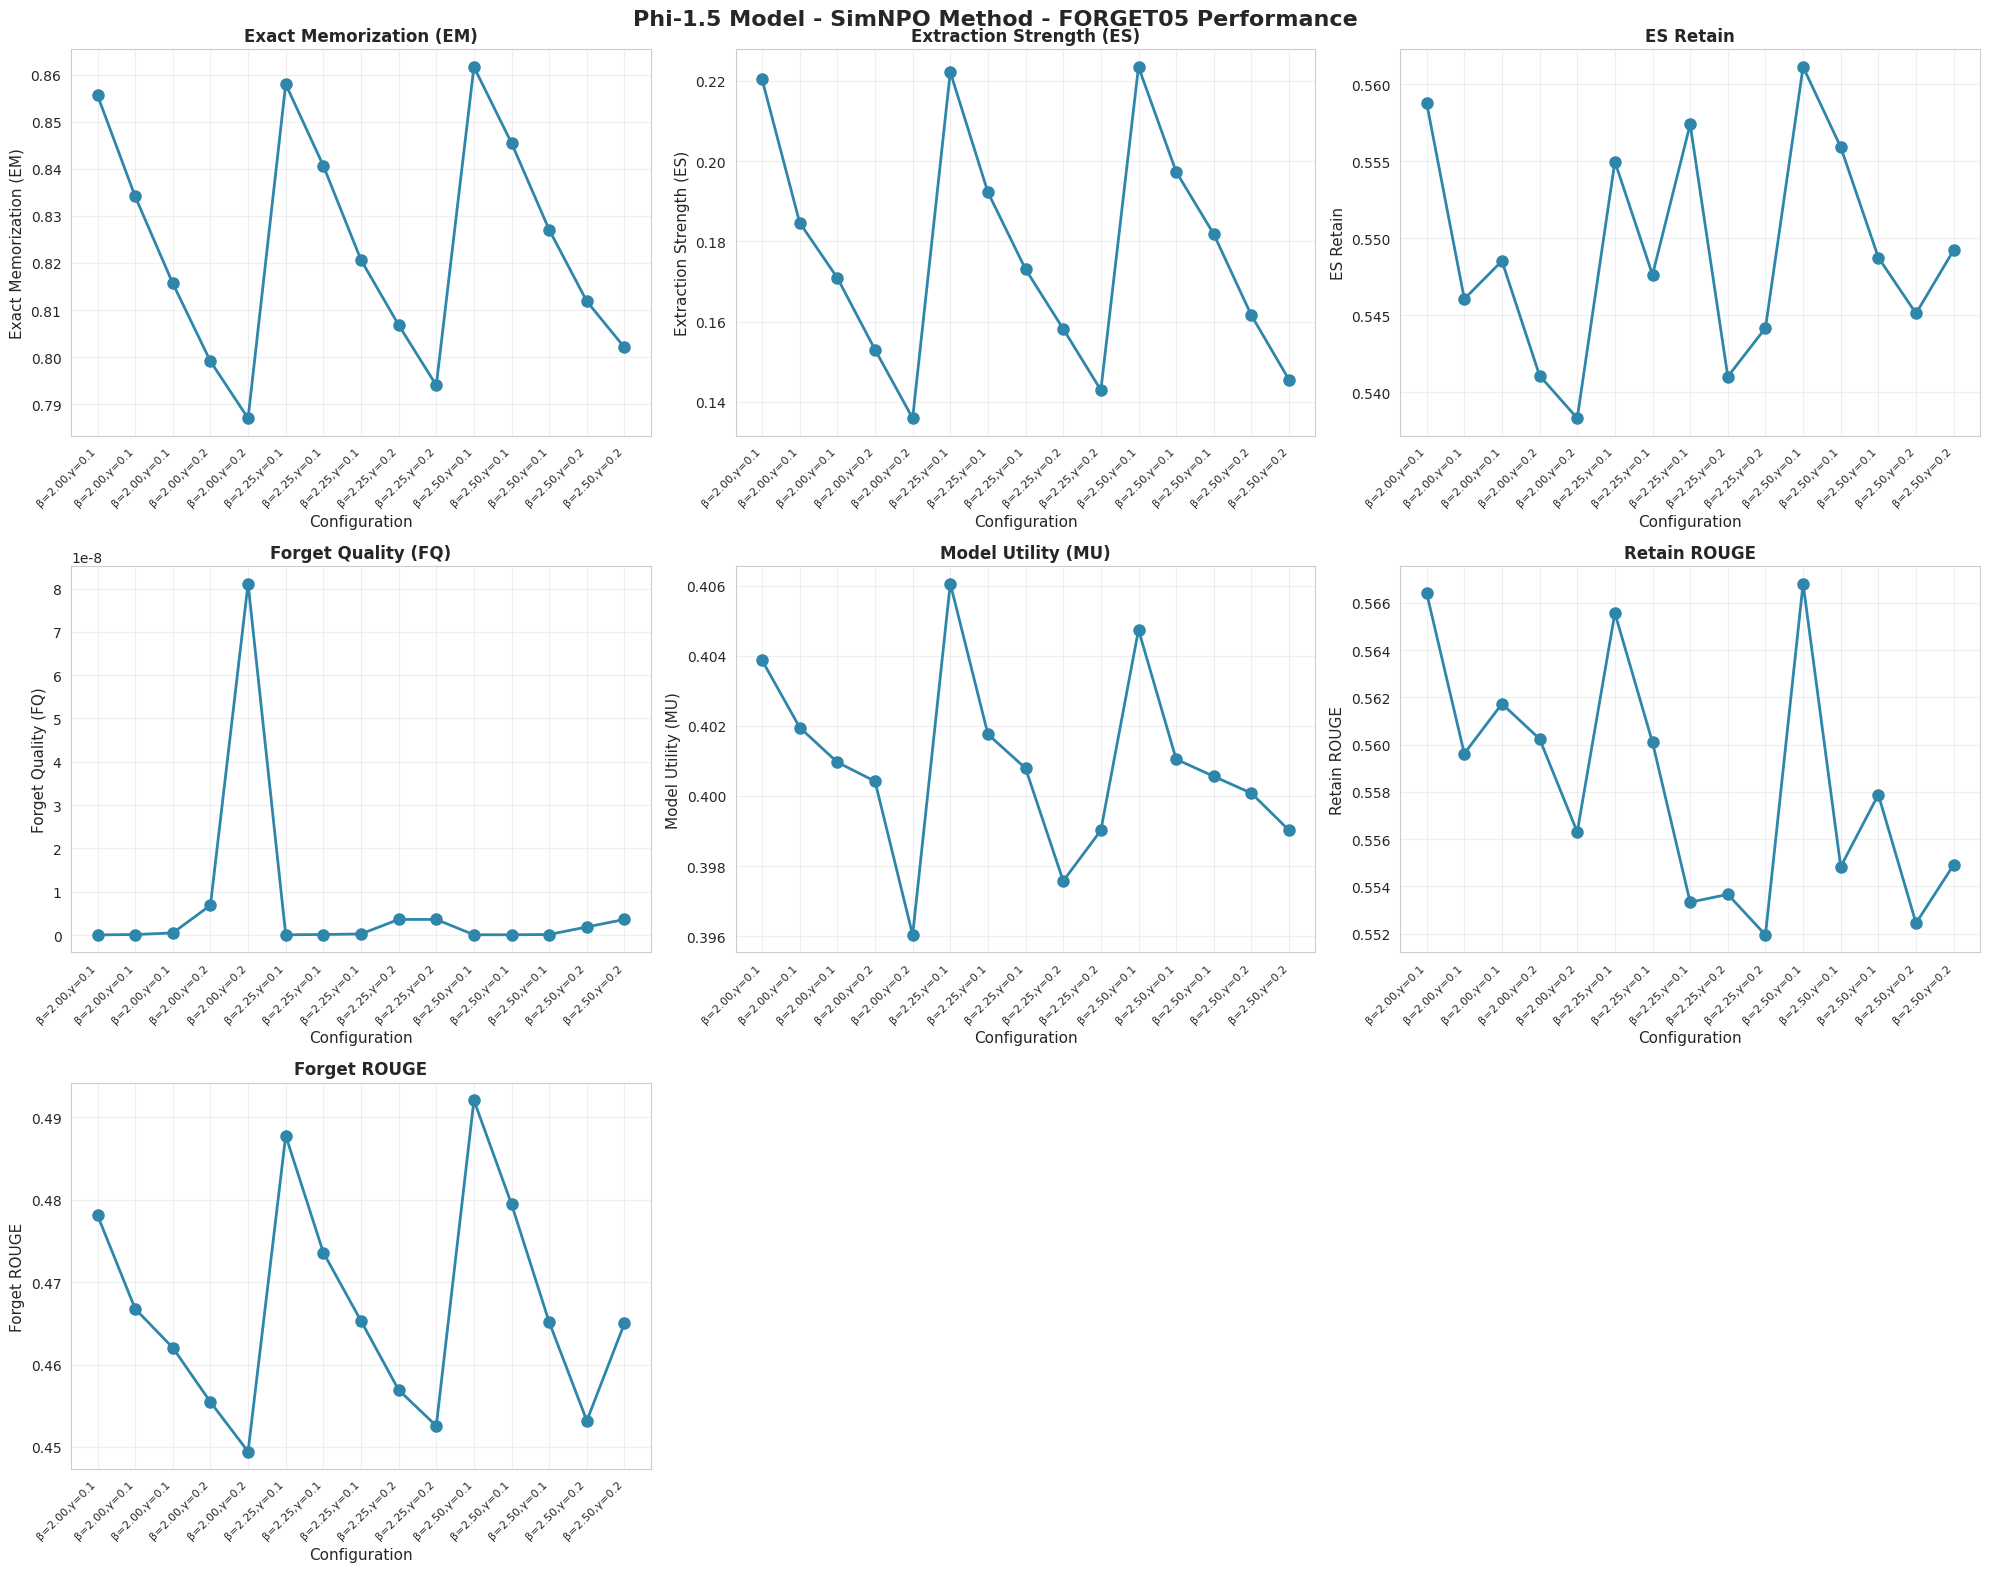

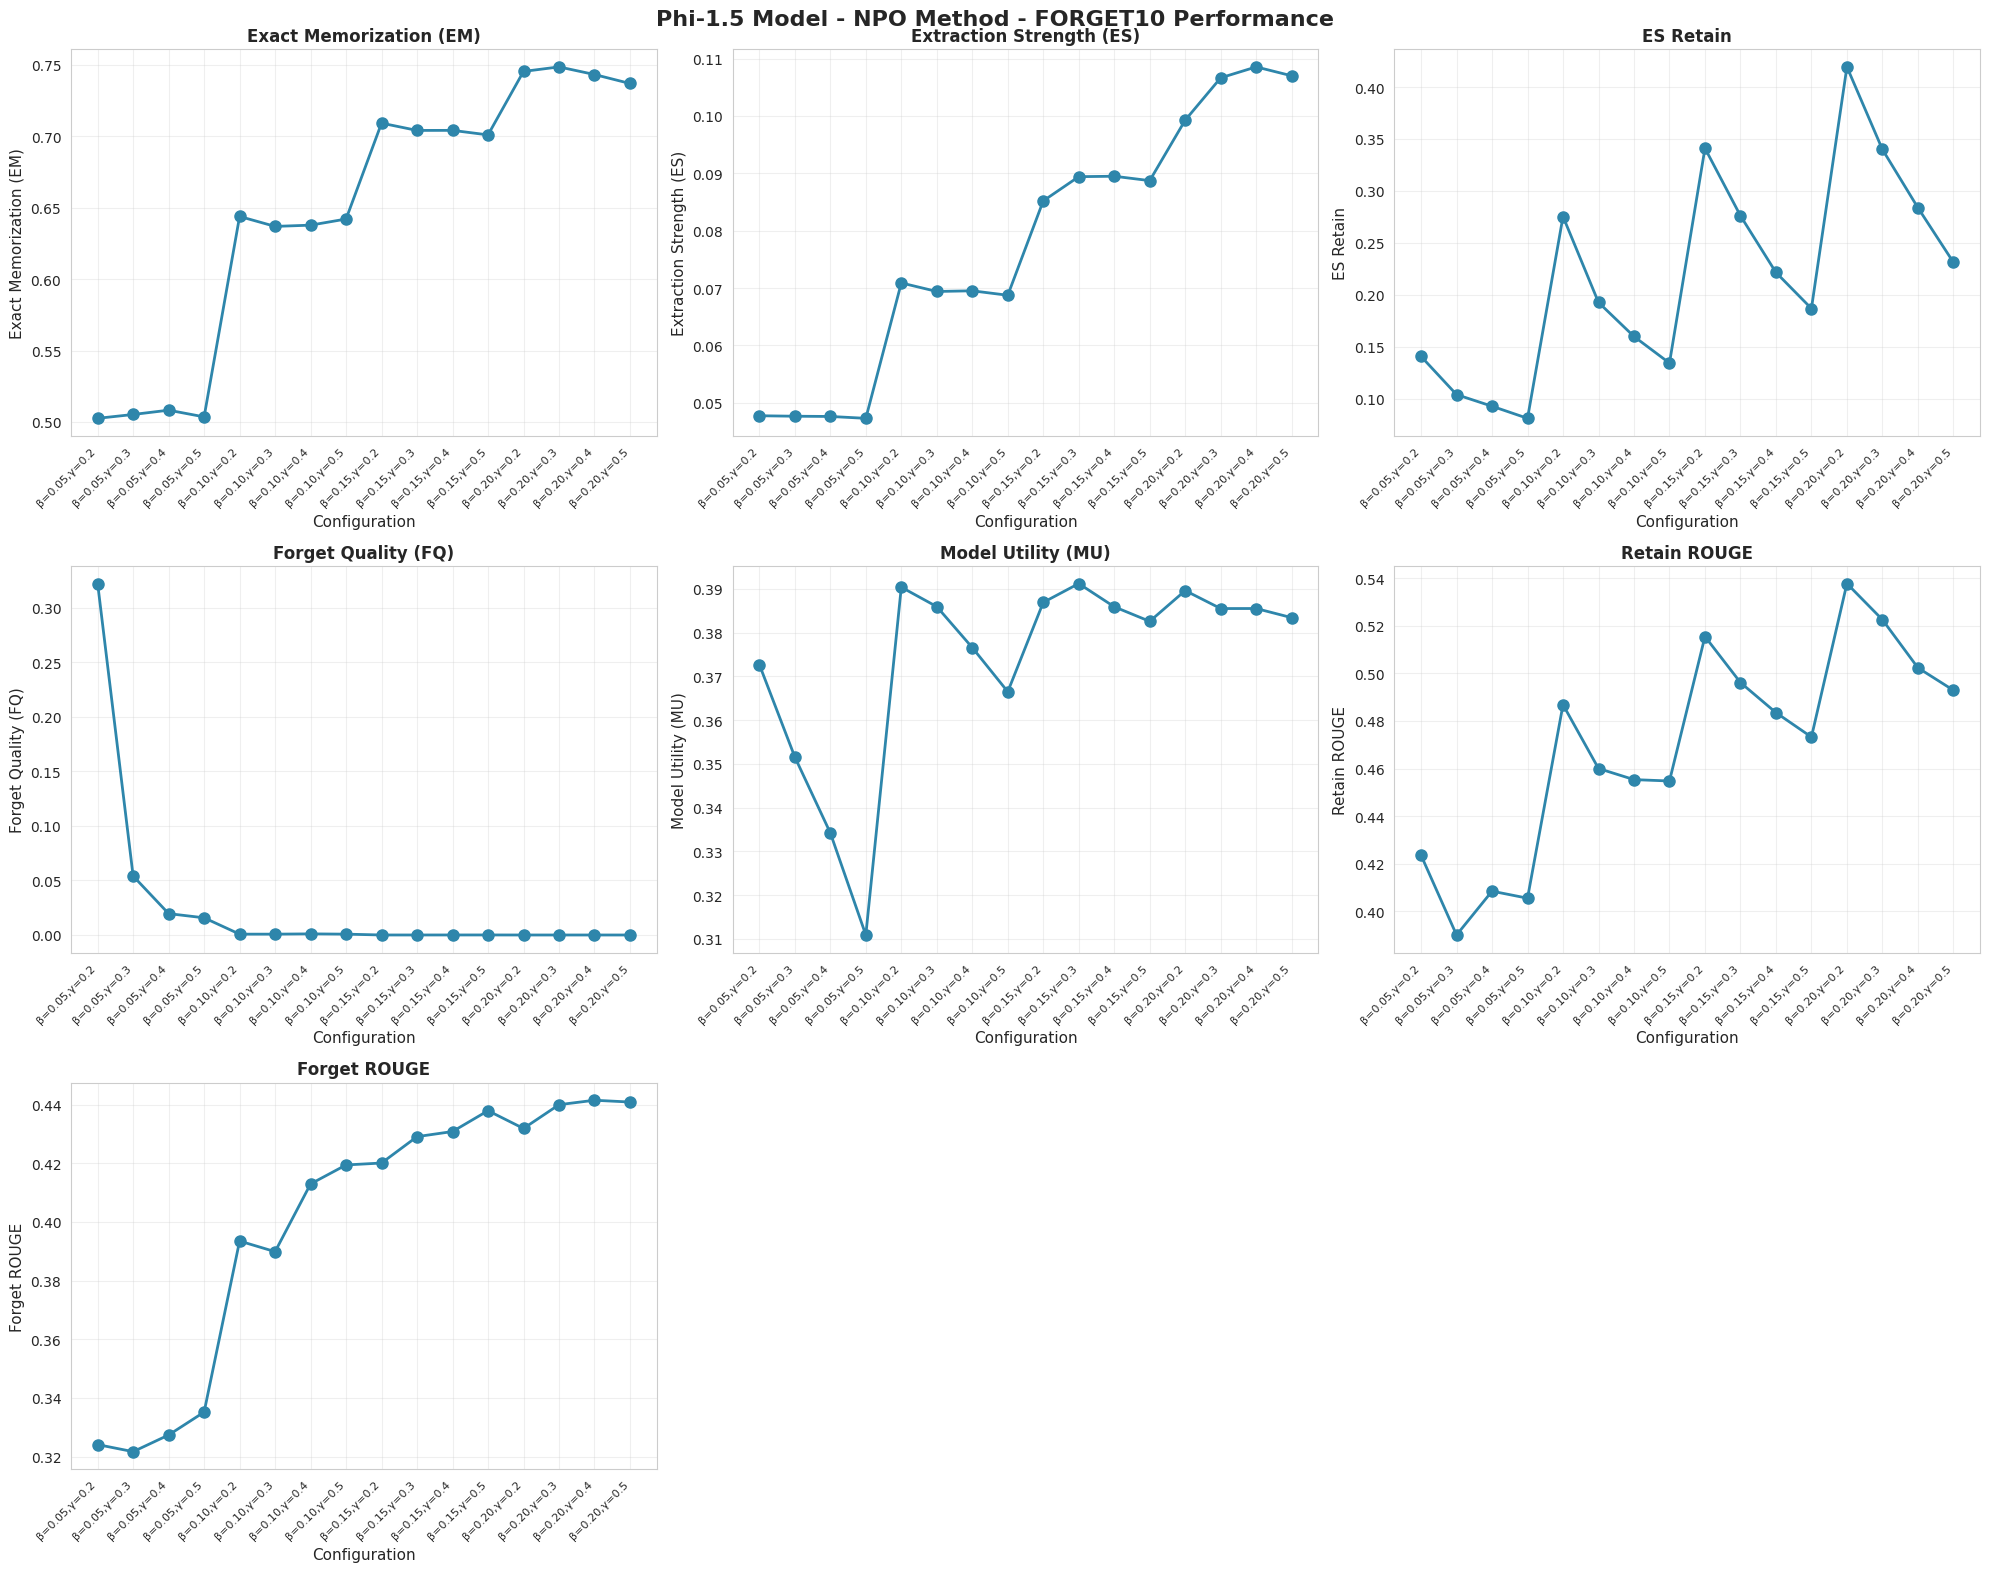

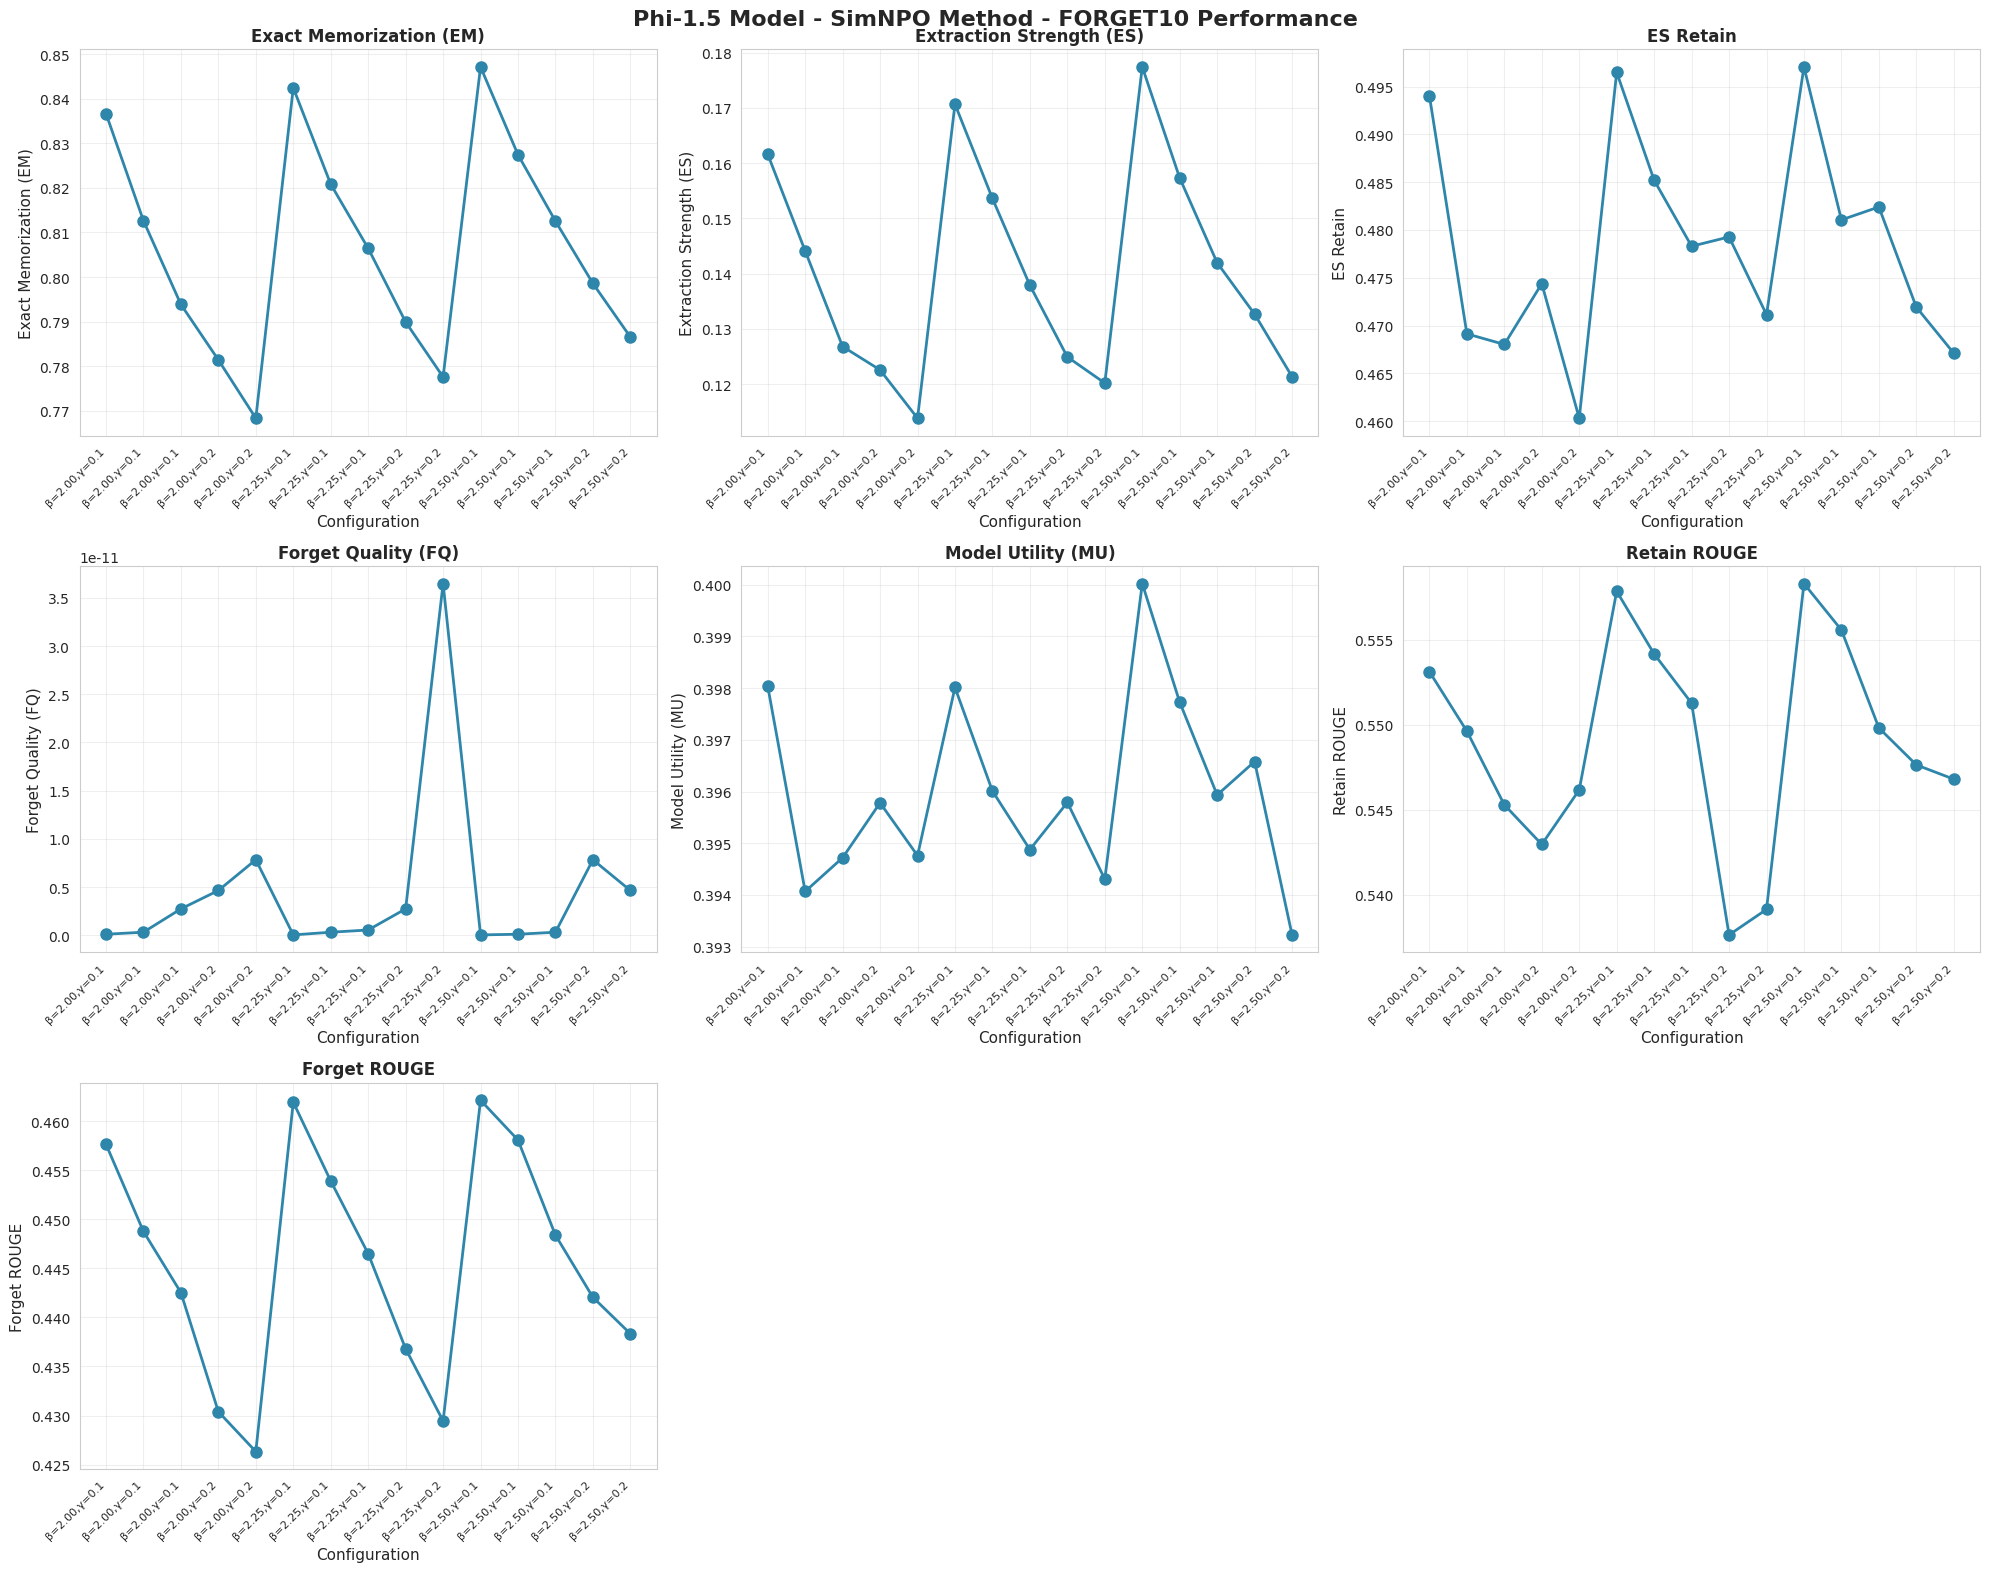

In [8]:
# Define metrics to analyze
metrics = [
    'exact_memorization',
    'extraction_strength',
    'extraction_strength_retain',
    'forget_quality',
    'model_utility',
    'retain_Q_A_ROUGE',
    'forget_Q_A_ROUGE'
]

metric_labels = {
    'exact_memorization': 'Exact Memorization (EM)',
    'extraction_strength': 'Extraction Strength (ES)',
    'extraction_strength_retain': 'ES Retain',
    'forget_quality': 'Forget Quality (FQ)',
    'model_utility': 'Model Utility (MU)',
    'retain_Q_A_ROUGE': 'Retain ROUGE',
    'forget_Q_A_ROUGE': 'Forget ROUGE'
}

# Create separate plots for each method and forget set
methods = df['method'].unique()
forget_sets = df['forget_set'].unique()

for forget_set in forget_sets:
    for method in methods:
        method_df = df[(df['method'] == method) & (df['forget_set'] == forget_set)].copy()
        
        if len(method_df) == 0:
            continue
        
        # Sort by hyperparameters
        if 'beta' in method_df.columns and method_df['beta'].notna().any():
            if 'gamma' in method_df.columns and method_df['gamma'].notna().any():
                # Sort by beta first, then gamma
                method_df = method_df.sort_values(['beta', 'gamma'])
                method_df['config'] = method_df.apply(lambda x: f"β={x['beta']:.2f},γ={x['gamma']:.1f}", axis=1)
            else:
                method_df = method_df.sort_values('beta')
                method_df['config'] = method_df['beta'].apply(lambda x: f"β={x:.2f}")
        else:
            method_df['config'] = range(len(method_df))
        
        fig, axes = plt.subplots(3, 3, figsize=(20, 16))
        axes = axes.flatten()
        fig.suptitle(f'{model_name} Model - {method} Method - {forget_set.upper()} Performance', fontsize=16, fontweight='bold')
        
        for idx, metric in enumerate(metrics):
            ax = axes[idx]
            
            x_pos = range(len(method_df))
            ax.plot(x_pos, method_df[metric], marker='o', linewidth=2, markersize=8, color='#2E86AB')
            
            ax.set_xlabel('Configuration', fontsize=11)
            ax.set_ylabel(metric_labels[metric], fontsize=11)
            ax.set_title(metric_labels[metric], fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            # Set x-tick labels
            if len(method_df) <= 20:
                ax.set_xticks(x_pos)
                ax.set_xticklabels(method_df['config'], rotation=45, ha='right', fontsize=8)
            else:
                # Show fewer labels if too many points
                step = len(method_df) // 10
                ax.set_xticks(x_pos[::step])
                ax.set_xticklabels(method_df['config'].iloc[::step], rotation=45, ha='right', fontsize=8)
        
        # Hide extra subplots
        for idx in range(len(metrics), len(axes)):
            axes[idx].set_visible(False)
        
        plt.tight_layout()
        # filename = f'/cnz/data/project/my-open-unlearning/notebooks/metrics_{method}_{forget_set}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        # print(f"Saved: {filename}")

## 4. Hyperparameter Impact Analysis

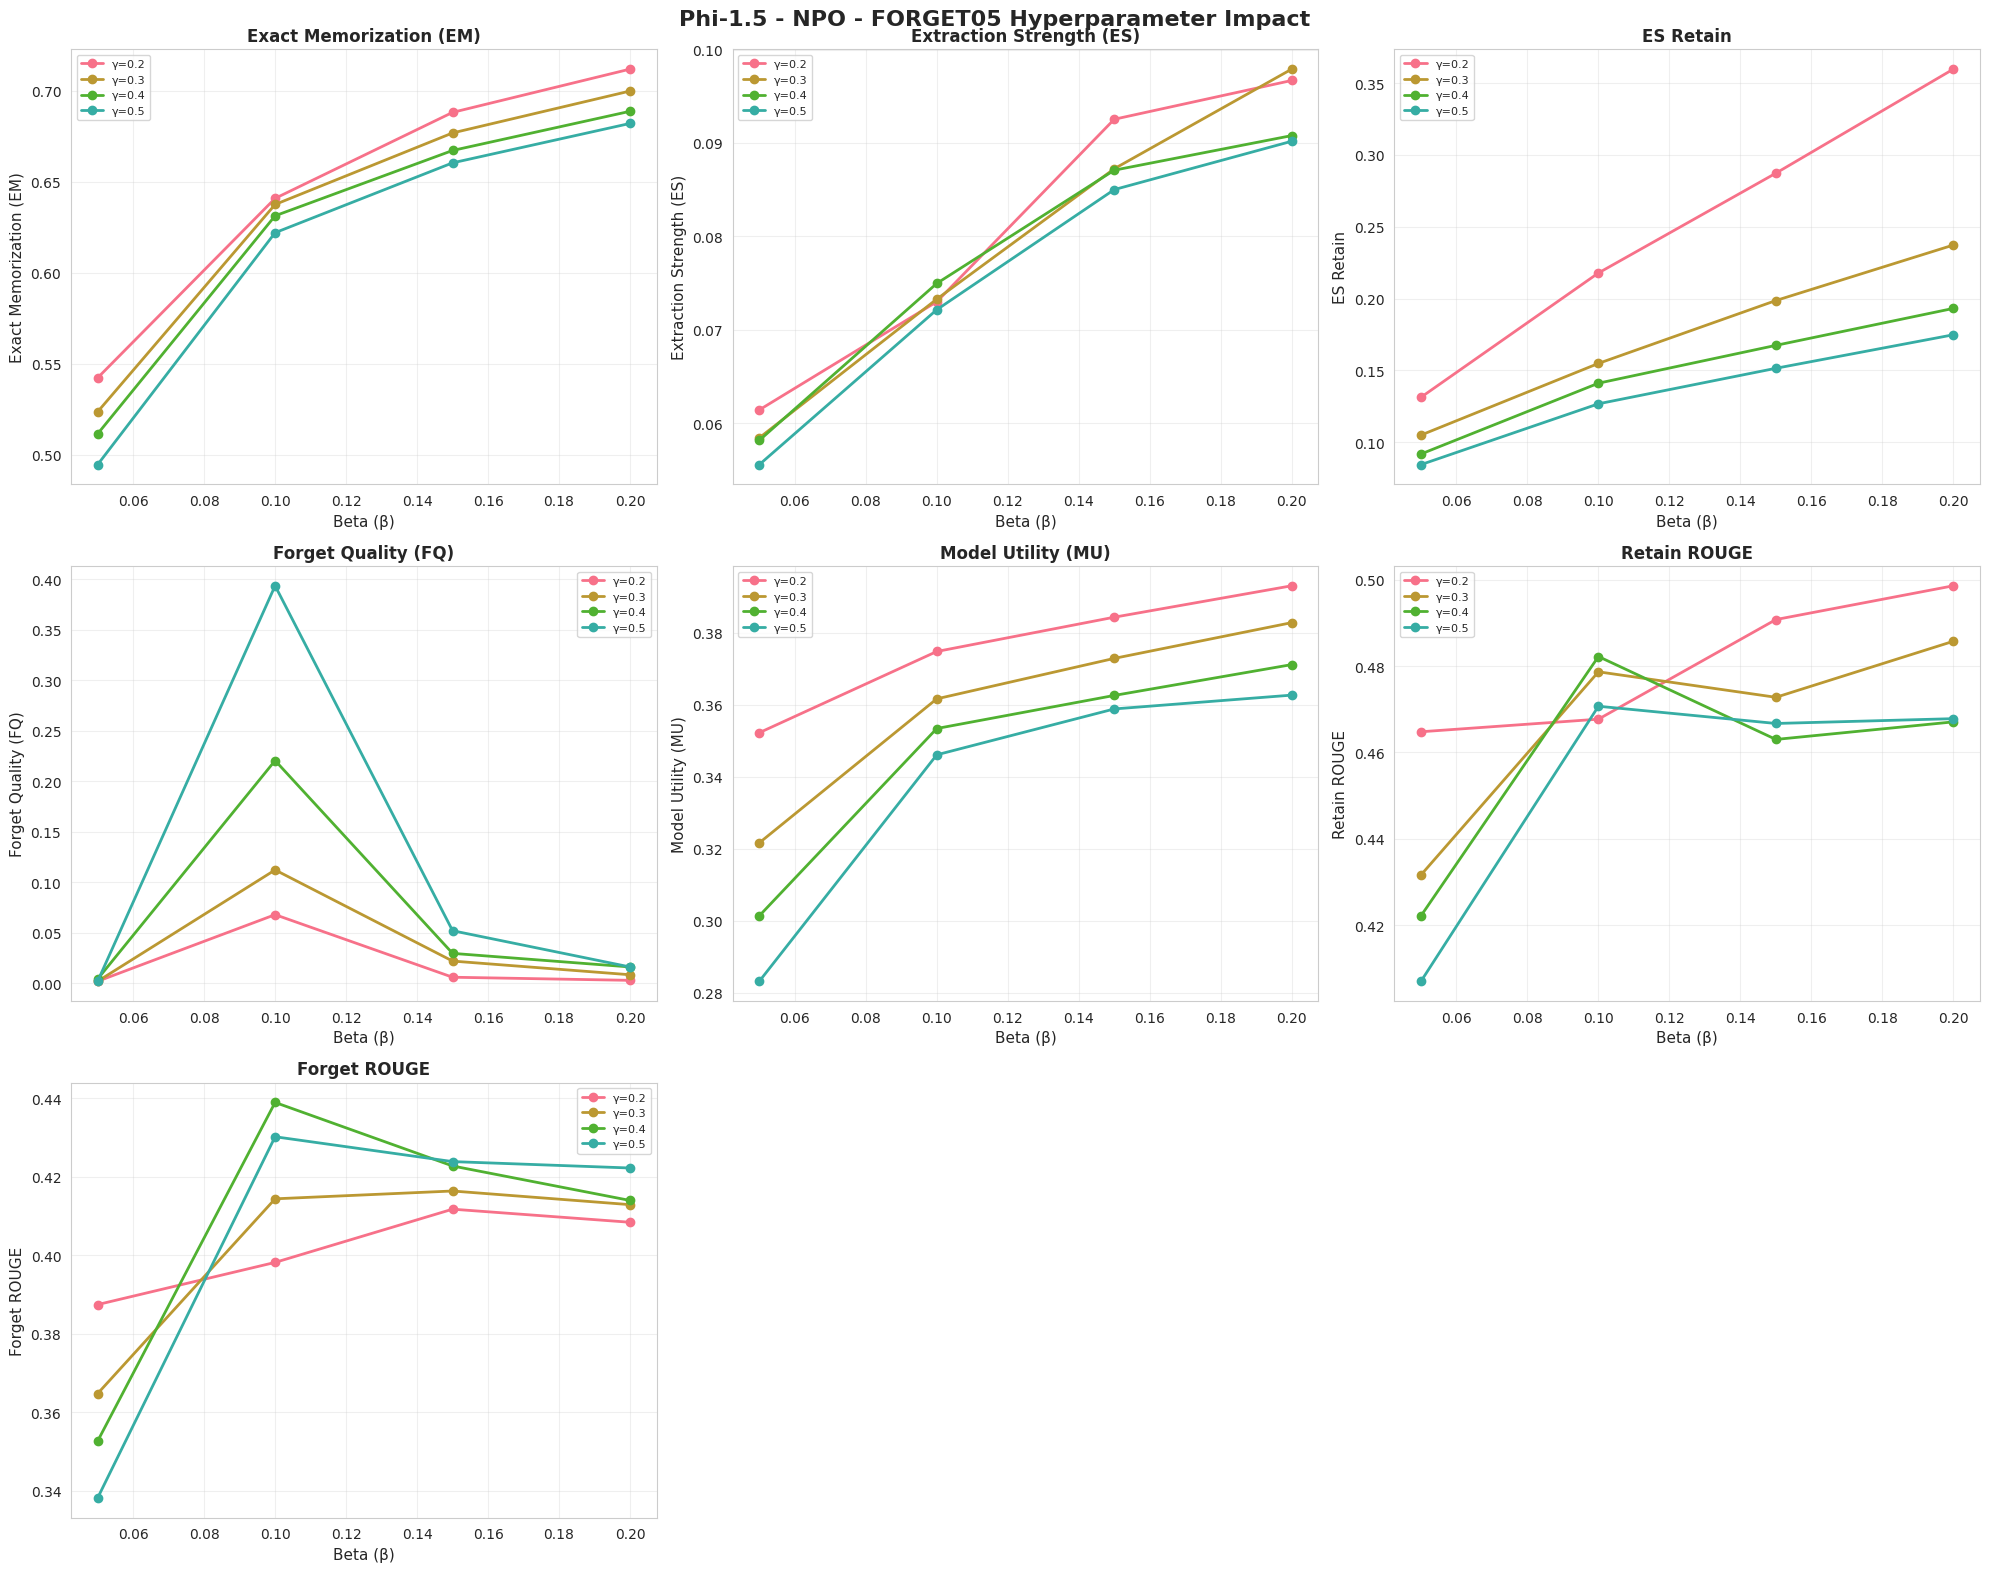

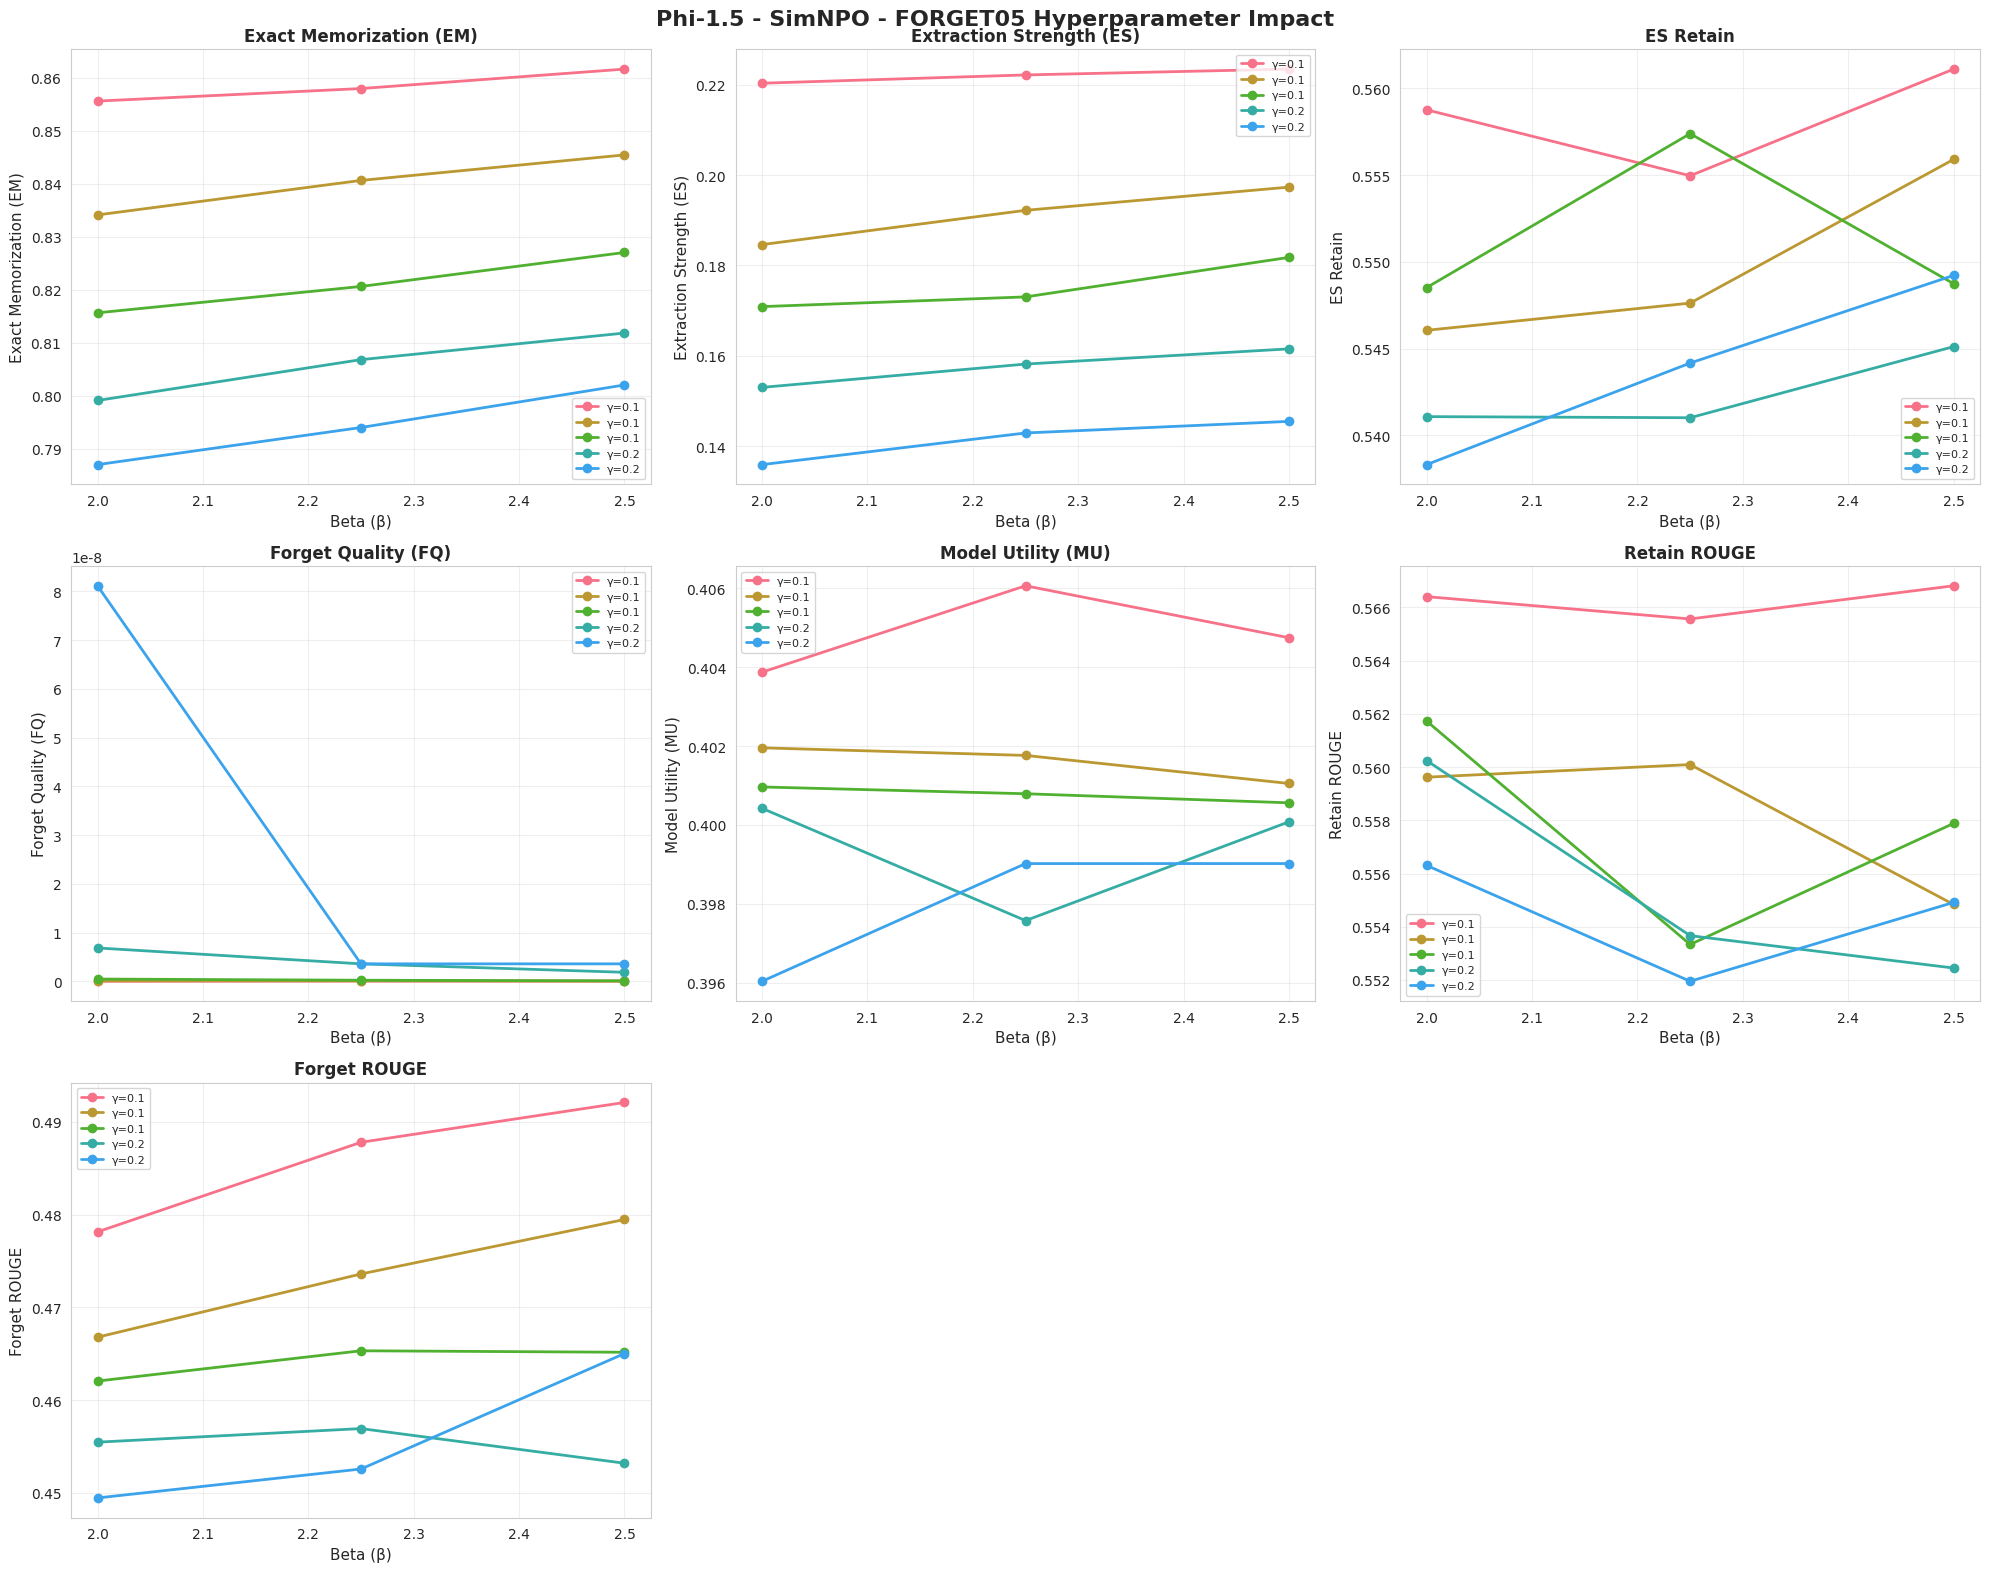

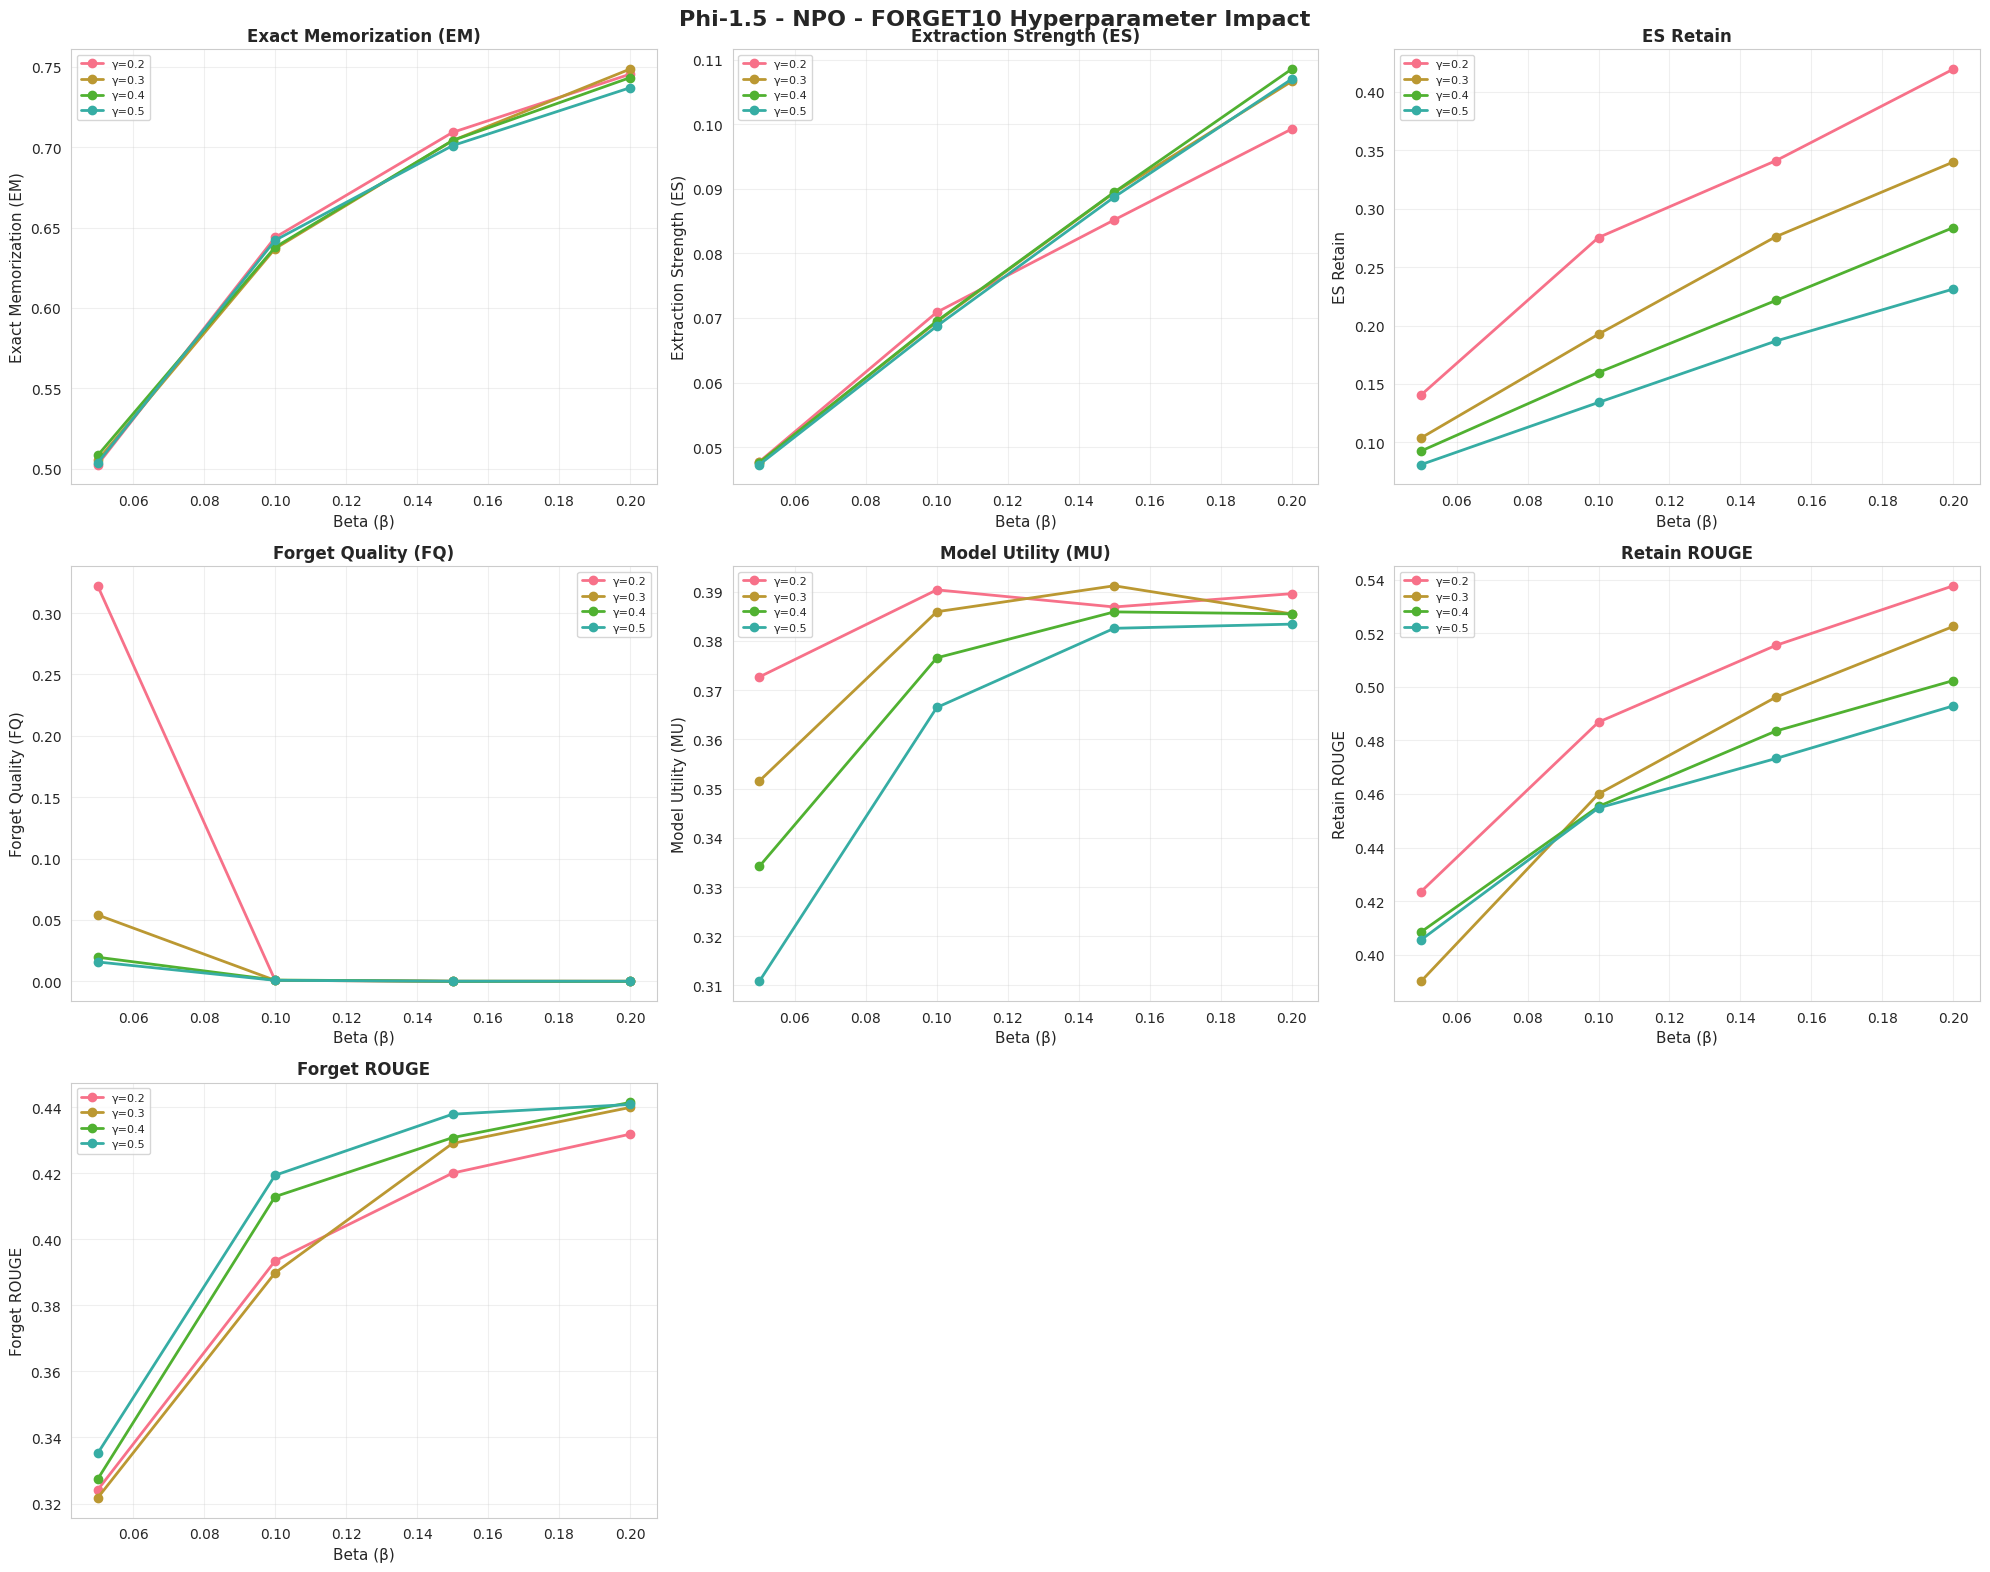

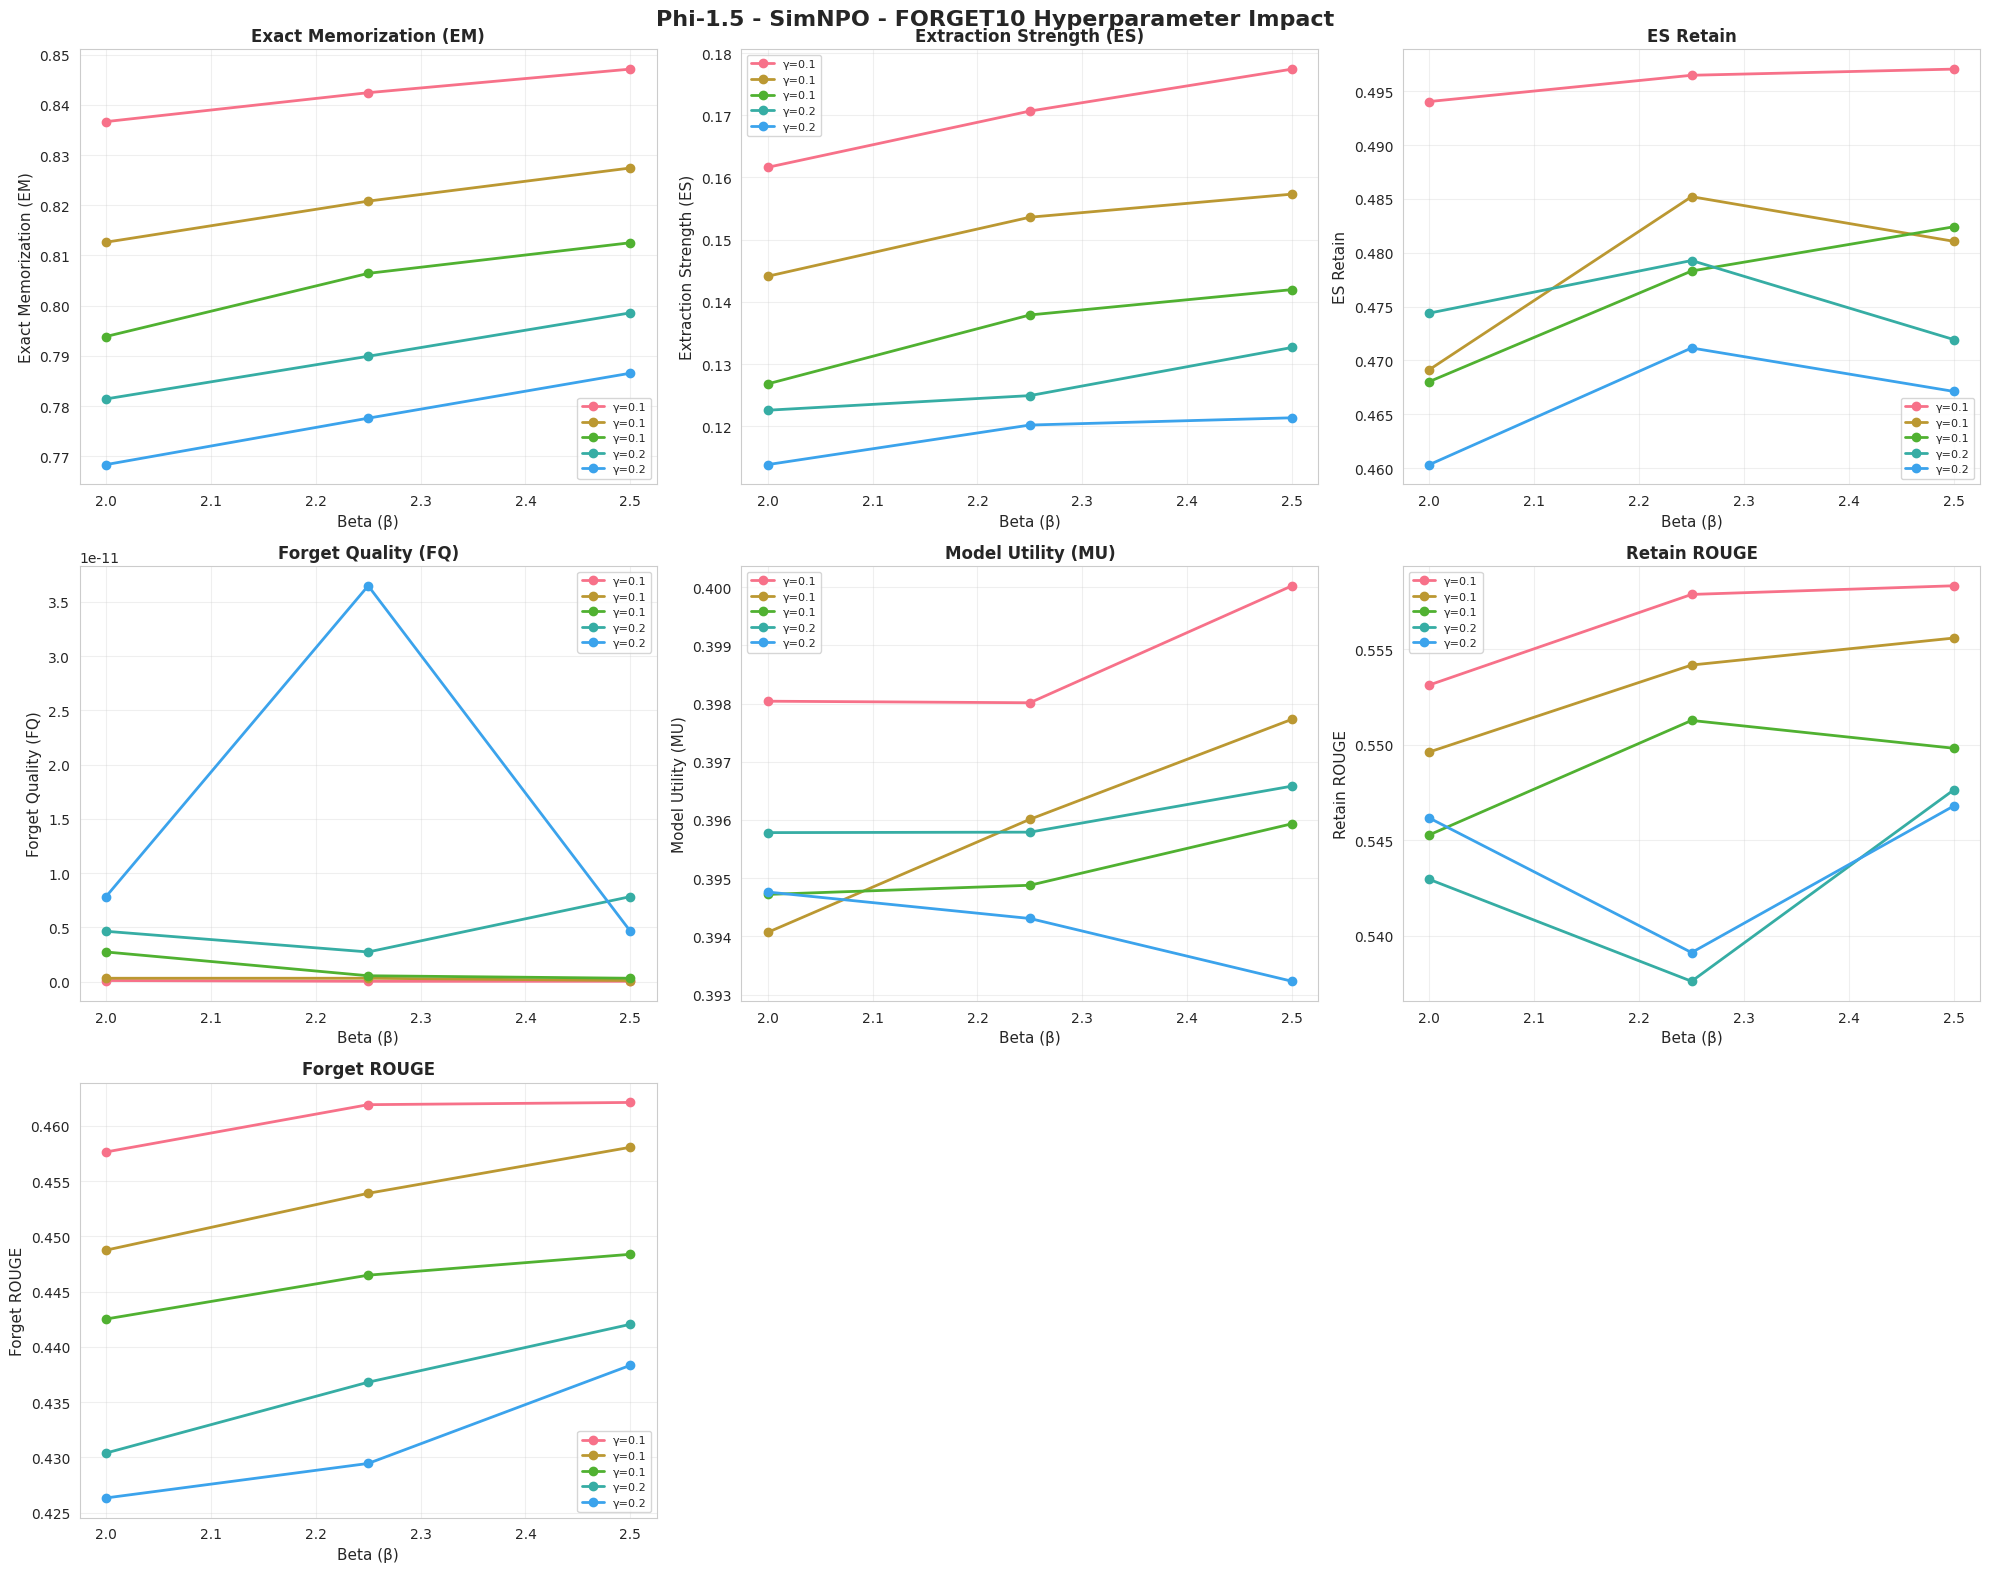

In [9]:
# Analyze hyperparameter impact for each method and forget set
for forget_set in forget_sets:
    for method in methods:
        method_df = df[(df['method'] == method) & (df['forget_set'] == forget_set)].copy()
        
        if len(method_df) < 2:
            continue
        
        # Check if beta and gamma exist
        has_beta = 'beta' in method_df.columns and method_df['beta'].notna().any()
        has_gamma = 'gamma' in method_df.columns and method_df['gamma'].notna().any()
        
        if not (has_beta or has_gamma):
            continue
        
        fig, axes = plt.subplots(3, 3, figsize=(20, 16))
        axes = axes.flatten()
        fig.suptitle(f'{model_name} - {method} - {forget_set.upper()} Hyperparameter Impact', fontsize=16, fontweight='bold')
        
        for idx, metric in enumerate(metrics):
            ax = axes[idx]
            
            if has_beta and has_gamma:
                # Group by gamma and plot lines for different gamma values
                for gamma_val in sorted(method_df['gamma'].unique()):
                    gamma_df = method_df[method_df['gamma'] == gamma_val].sort_values('beta')
                    if len(gamma_df) > 0:
                        ax.plot(gamma_df['beta'], gamma_df[metric], 
                               marker='o', label=f'γ={gamma_val:.1f}', linewidth=2, markersize=6)
                ax.set_xlabel('Beta (β)', fontsize=11)
                ax.legend(loc='best', fontsize=8)
            elif has_beta:
                method_df_sorted = method_df.sort_values('beta')
                ax.plot(method_df_sorted['beta'], method_df_sorted[metric], 
                       marker='o', linewidth=2, markersize=8, color='#2E86AB')
                ax.set_xlabel('Beta (β)', fontsize=11)
            elif has_gamma:
                method_df_sorted = method_df.sort_values('gamma')
                ax.plot(method_df_sorted['gamma'], method_df_sorted[metric], 
                       marker='o', linewidth=2, markersize=8, color='#2E86AB')
                ax.set_xlabel('Gamma (γ)', fontsize=11)
            
            ax.set_ylabel(metric_labels[metric], fontsize=11)
            ax.set_title(metric_labels[metric], fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
        
        # Hide extra subplots
        for idx in range(len(metrics), len(axes)):
            axes[idx].set_visible(False)
        
        plt.tight_layout()
        # filename = f'/cnz/data/project/my-open-unlearning/notebooks/hyperparam_{method}_{forget_set}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        # print(f"Saved: {filename}")

## 5. Beta-Gamma Heatmaps (for methods with grid search)

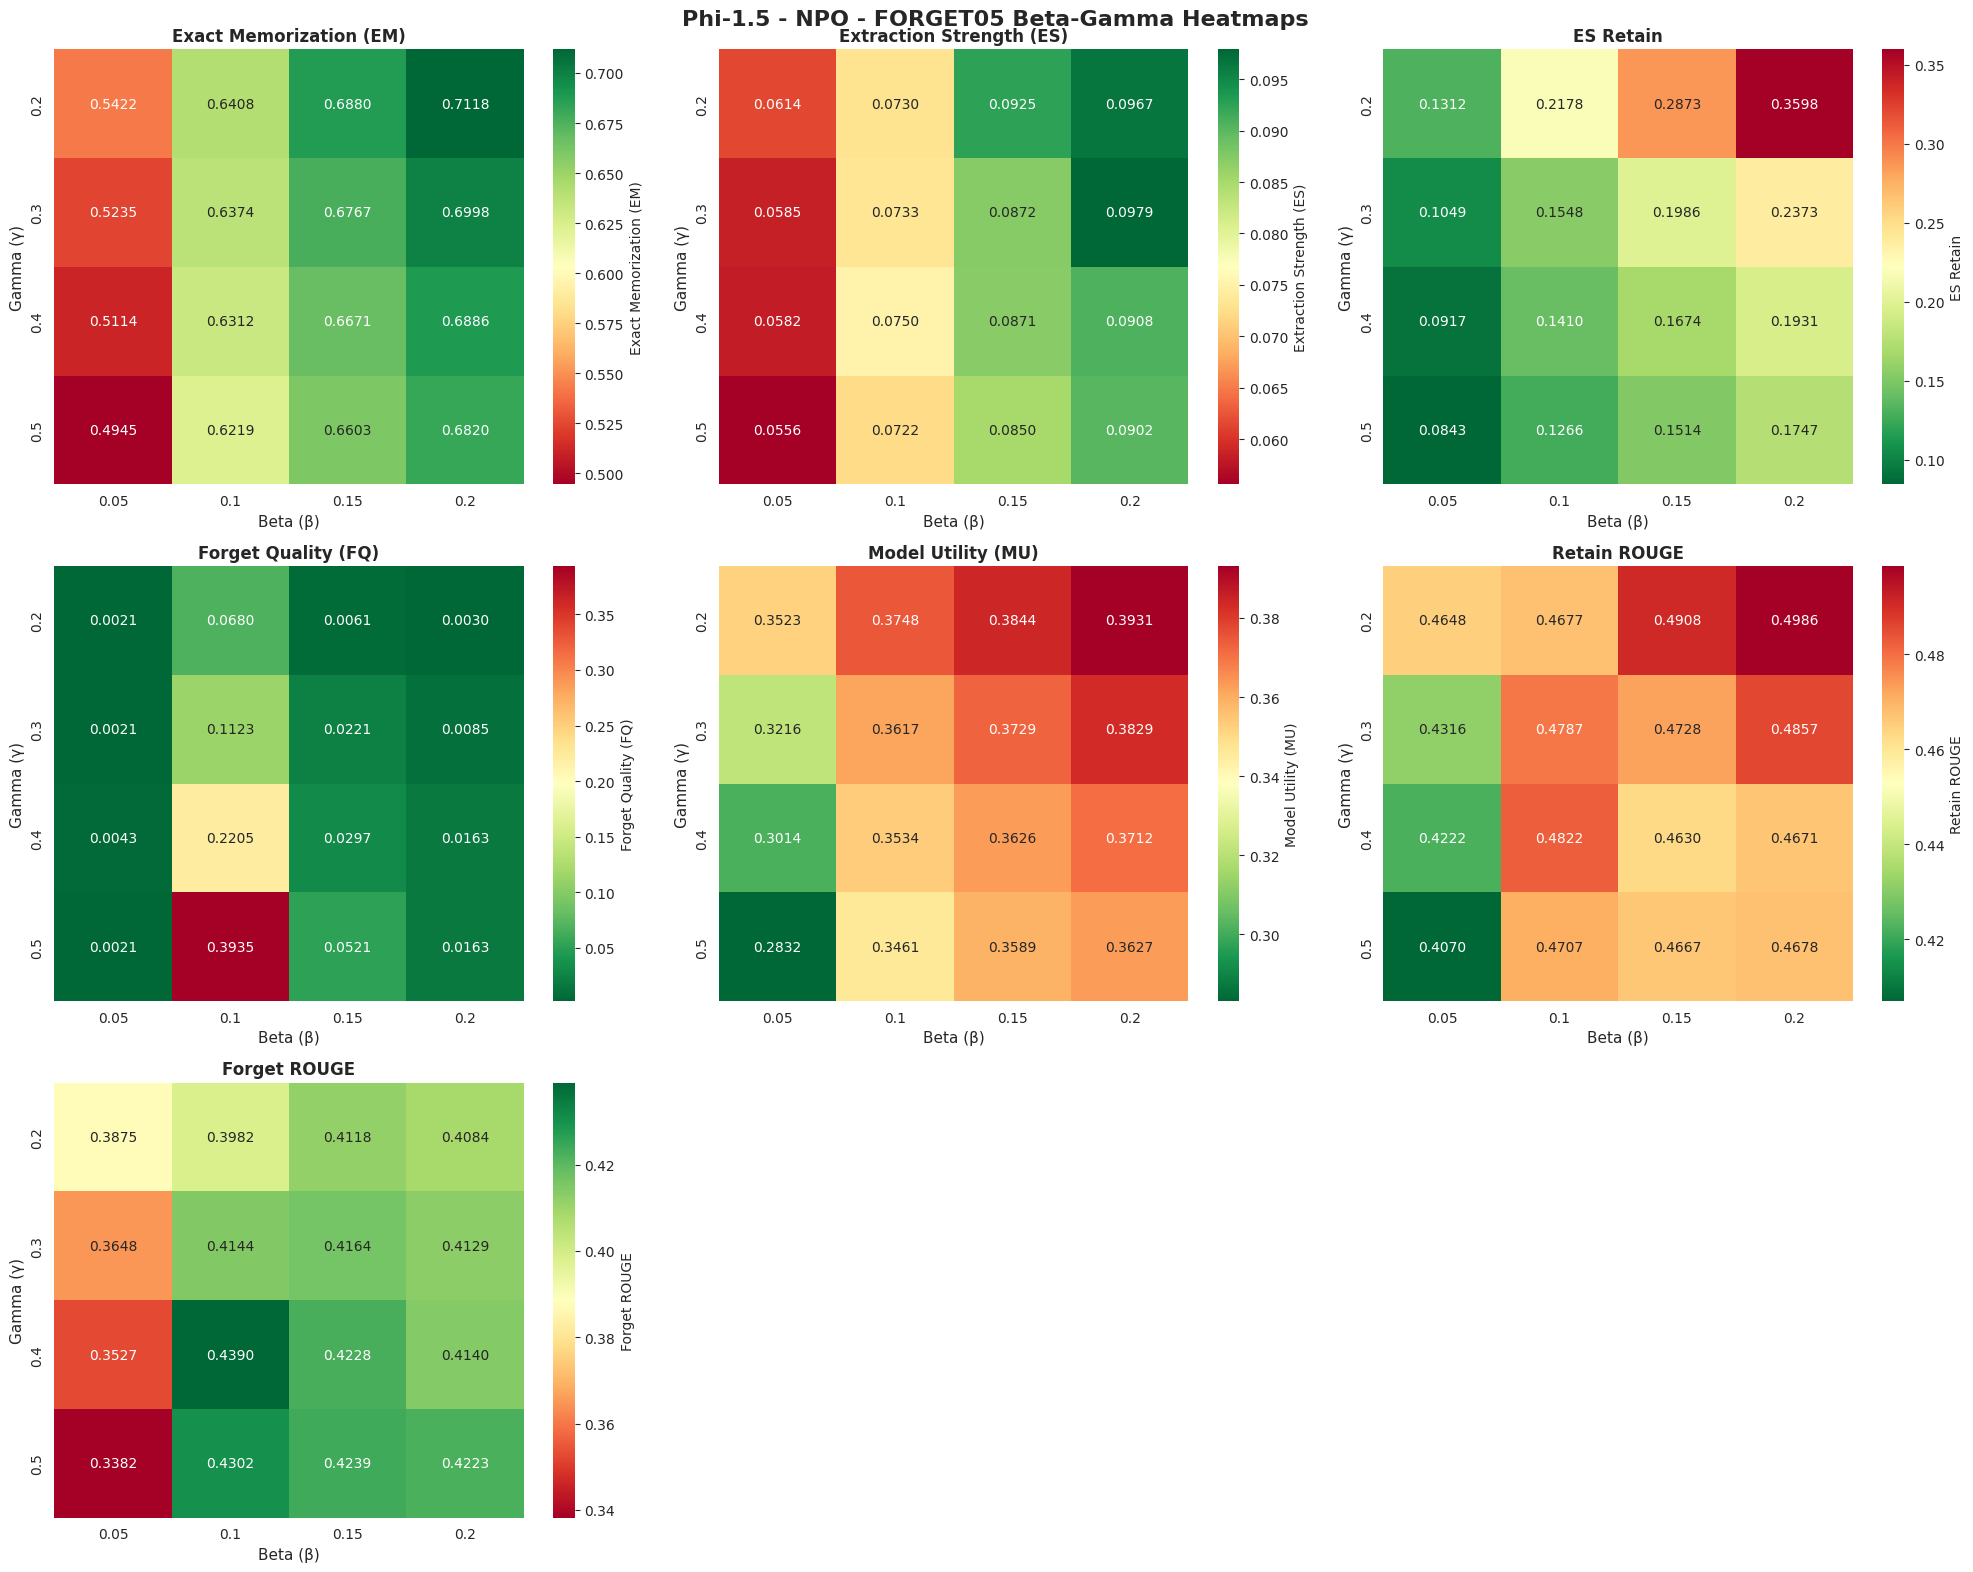

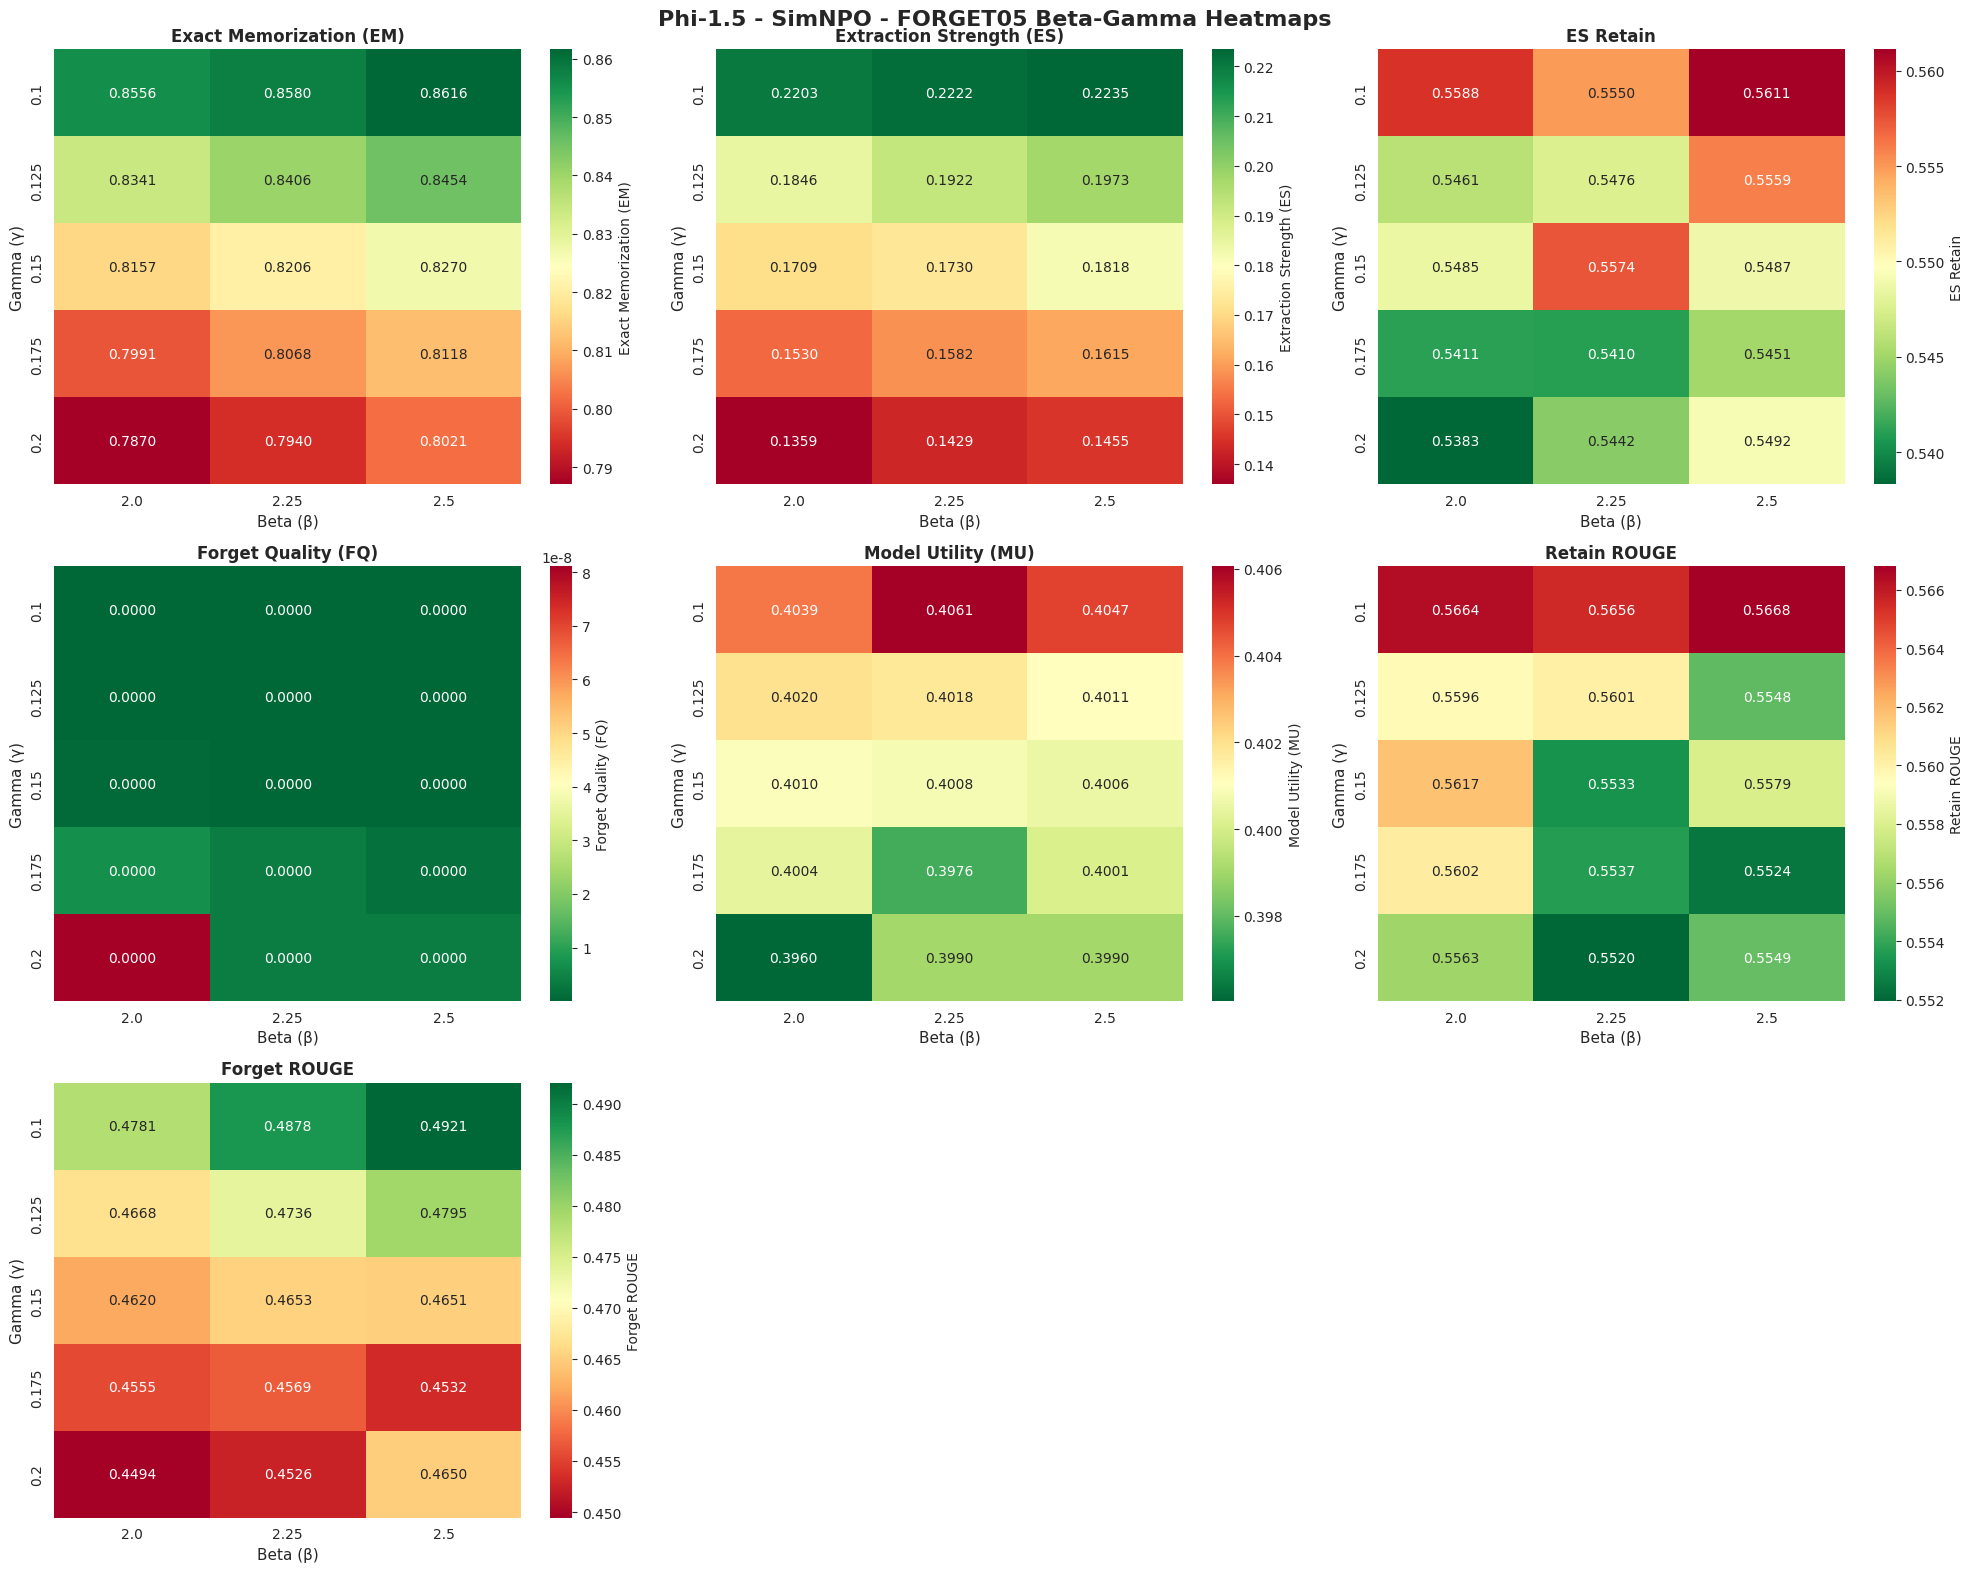

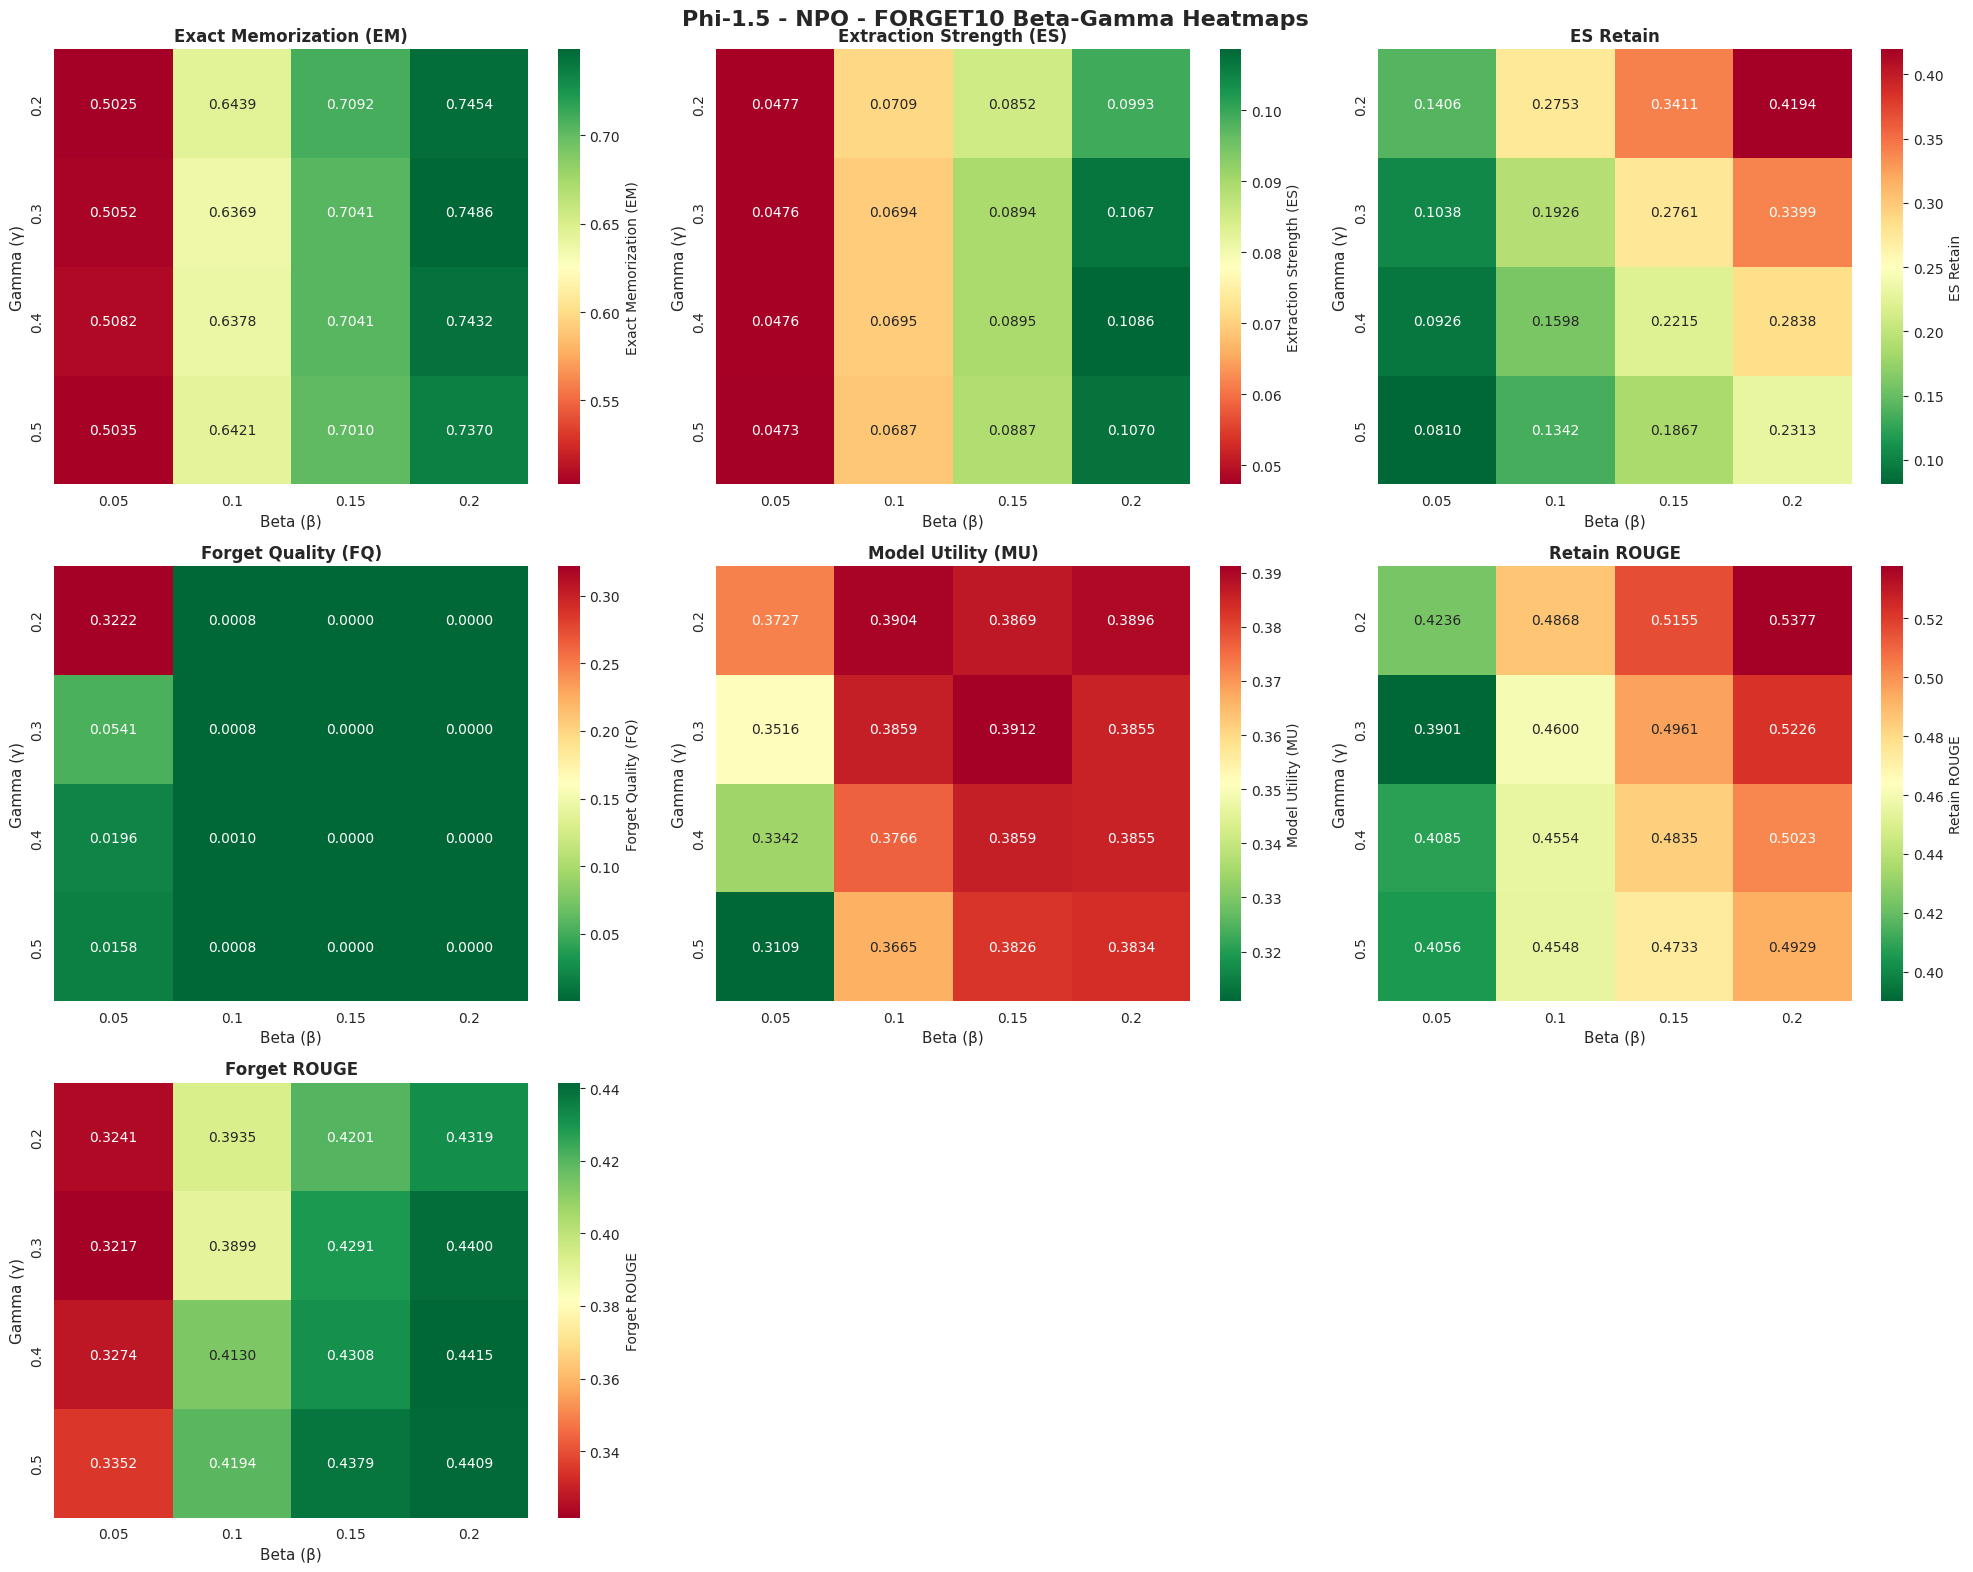

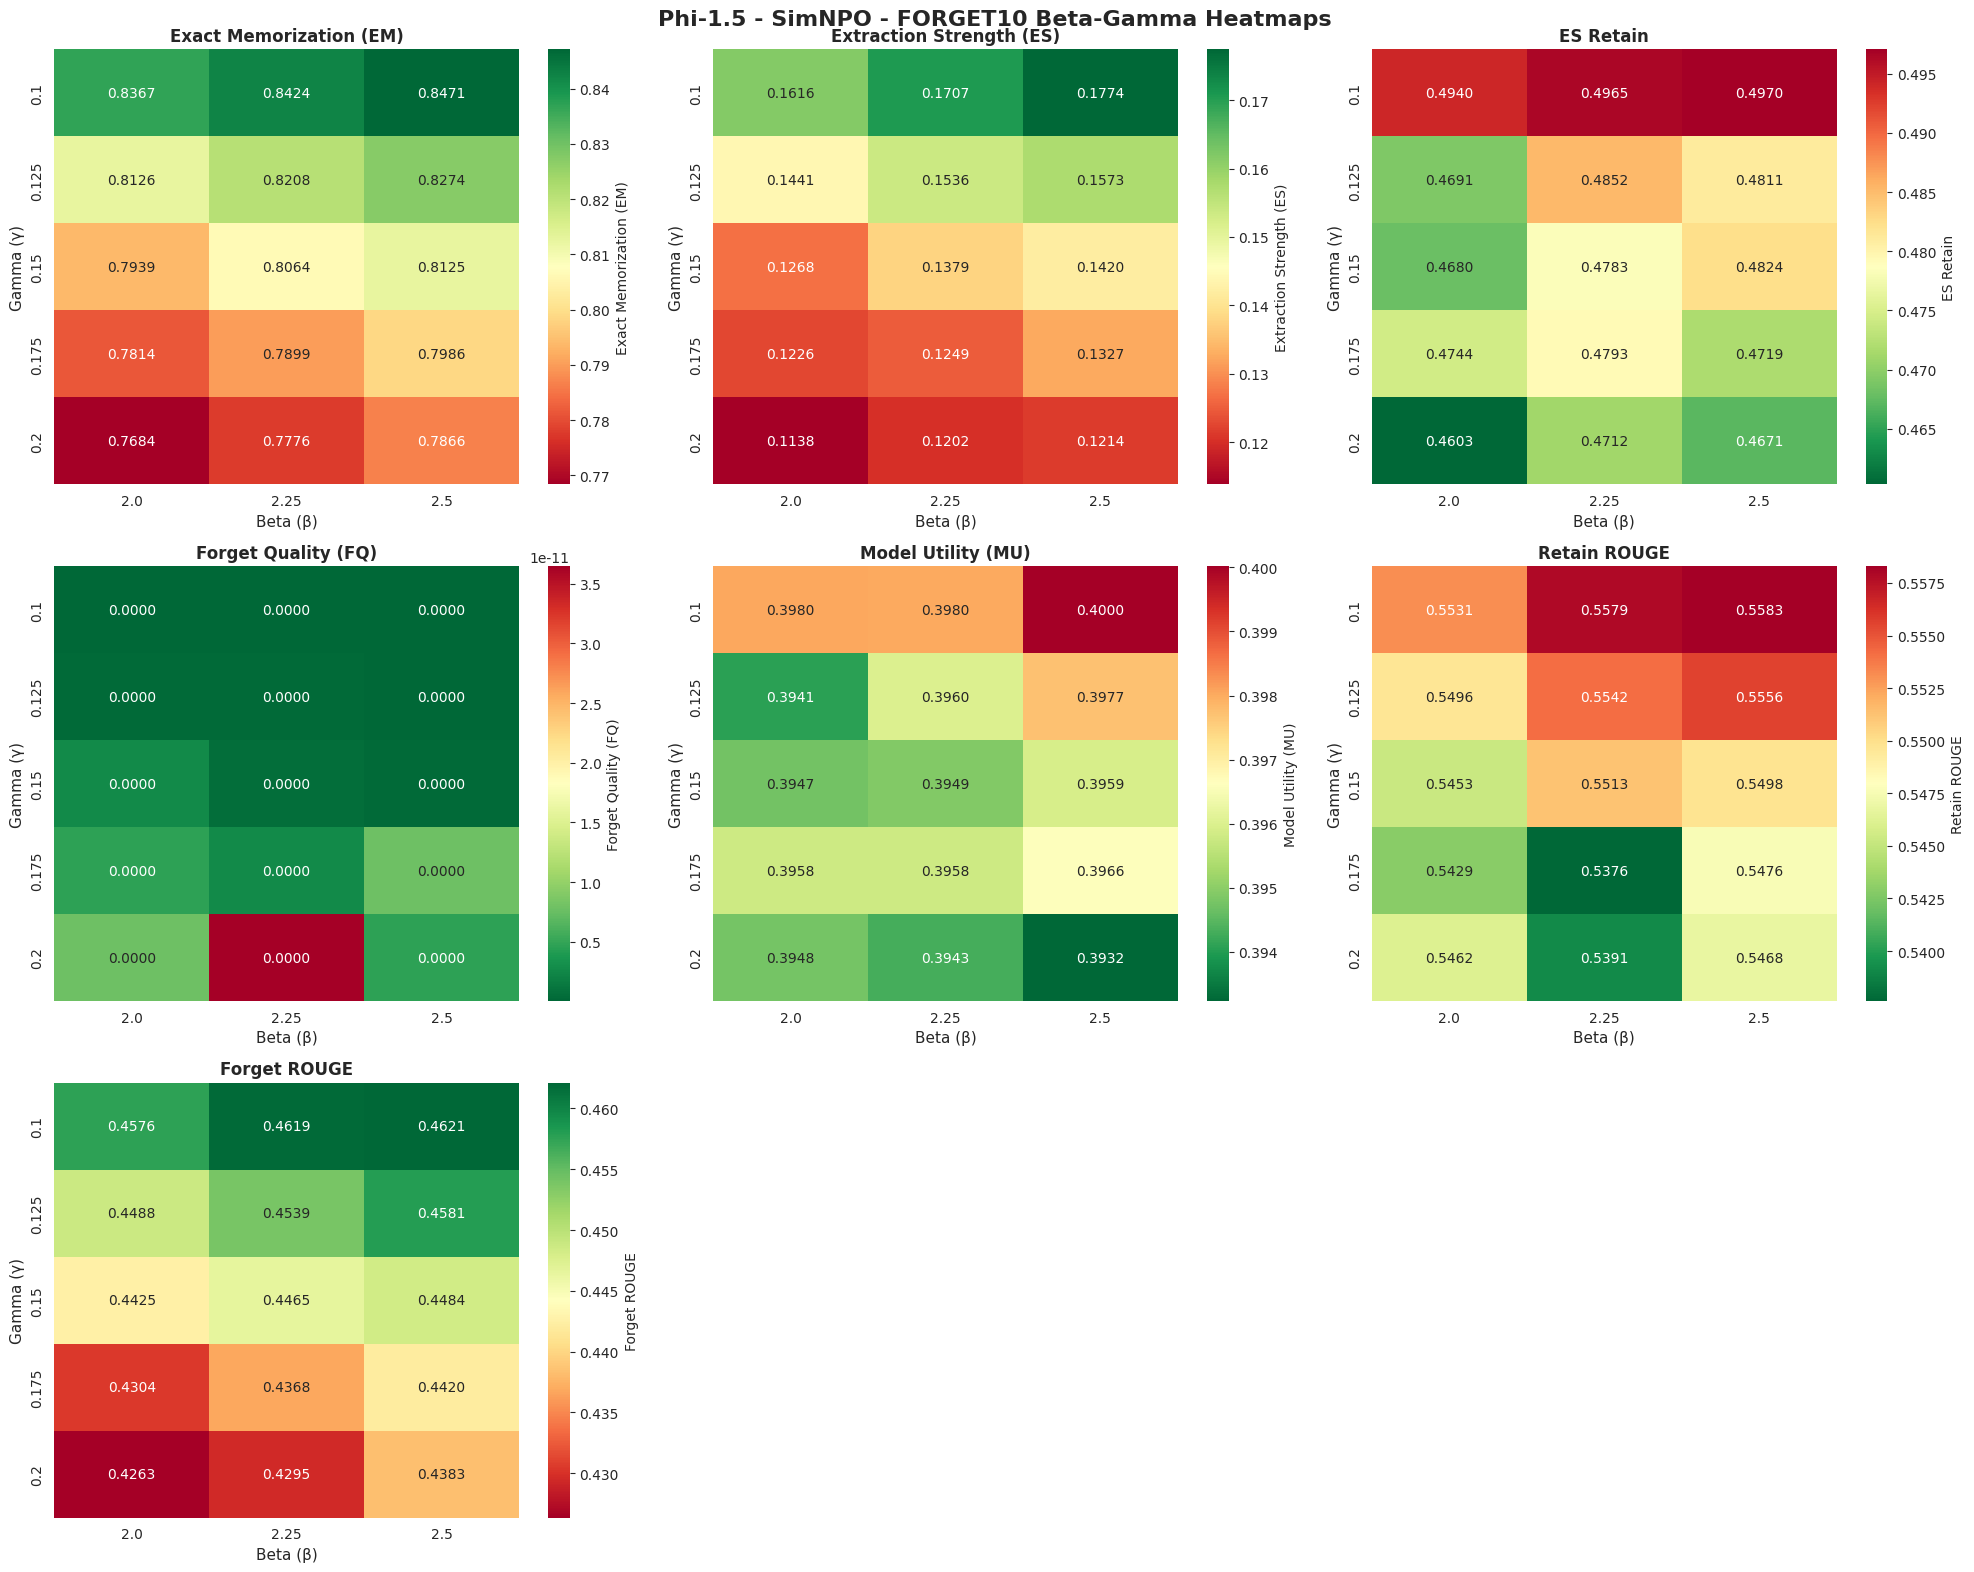

In [10]:
# Create heatmaps for methods with beta-gamma grid search
for forget_set in forget_sets:
    for method in methods:
        method_df = df[(df['method'] == method) & (df['forget_set'] == forget_set)].copy()
        
        if 'beta' not in method_df.columns or 'gamma' not in method_df.columns:
            continue
        
        # Filter for experiments with both beta and gamma
        grid_df = method_df[method_df['beta'].notna() & method_df['gamma'].notna()]
        
        if len(grid_df) < 4:  # Need at least 4 points for a meaningful heatmap
            continue
        
        fig, axes = plt.subplots(3, 3, figsize=(20, 16))
        axes = axes.flatten()
        fig.suptitle(f'{model_name} - {method} - {forget_set.upper()} Beta-Gamma Heatmaps', fontsize=16, fontweight='bold')
        
        for idx, metric in enumerate(metrics):
            ax = axes[idx]
            
            # Create pivot table
            pivot_table = grid_df.pivot_table(
                values=metric,
                index='gamma',
                columns='beta',
                aggfunc='mean'
            )
            
            # Choose colormap based on metric (lower is better vs higher is better)
            if metric in ['exact_memorization', 'extraction_strength', 'forget_Q_A_ROUGE']:
                # Lower is better - use reverse colormap (red=high/bad, green=low/good)
                cmap = 'RdYlGn'
            else:
                # Higher is better - use normal colormap (green=high/good, red=low/bad)
                cmap = 'RdYlGn_r'
            
            # Plot heatmap
            sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap=cmap, 
                       ax=ax, cbar_kws={'label': metric_labels[metric]},
                       vmin=pivot_table.min().min(), vmax=pivot_table.max().max())
            ax.set_title(metric_labels[metric], fontsize=12, fontweight='bold')
            ax.set_xlabel('Beta (β)', fontsize=11)
            ax.set_ylabel('Gamma (γ)', fontsize=11)
        
        # Hide extra subplots
        for idx in range(len(metrics), len(axes)):
            axes[idx].set_visible(False)
        
        plt.tight_layout()
        # filename = f'/cnz/data/project/my-open-unlearning/notebooks/heatmap_{method}_{forget_set}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        # print(f"Saved: {filename}")

## 6. Method Comparison


Average metric performance per method - FORGET05
        exact_memorization  extraction_strength  extraction_strength_retain  \
method                                                                        
NPO                 0.6298               0.0784                      0.1764   
SimNPO              0.8240               0.1775                      0.5492   

        forget_quality  model_utility  retain_Q_A_ROUGE  forget_Q_A_ROUGE  
method                                                                     
NPO             0.0599         0.3552            0.4648            0.4036  
SimNPO          0.0000         0.4009            0.5584            0.4669  


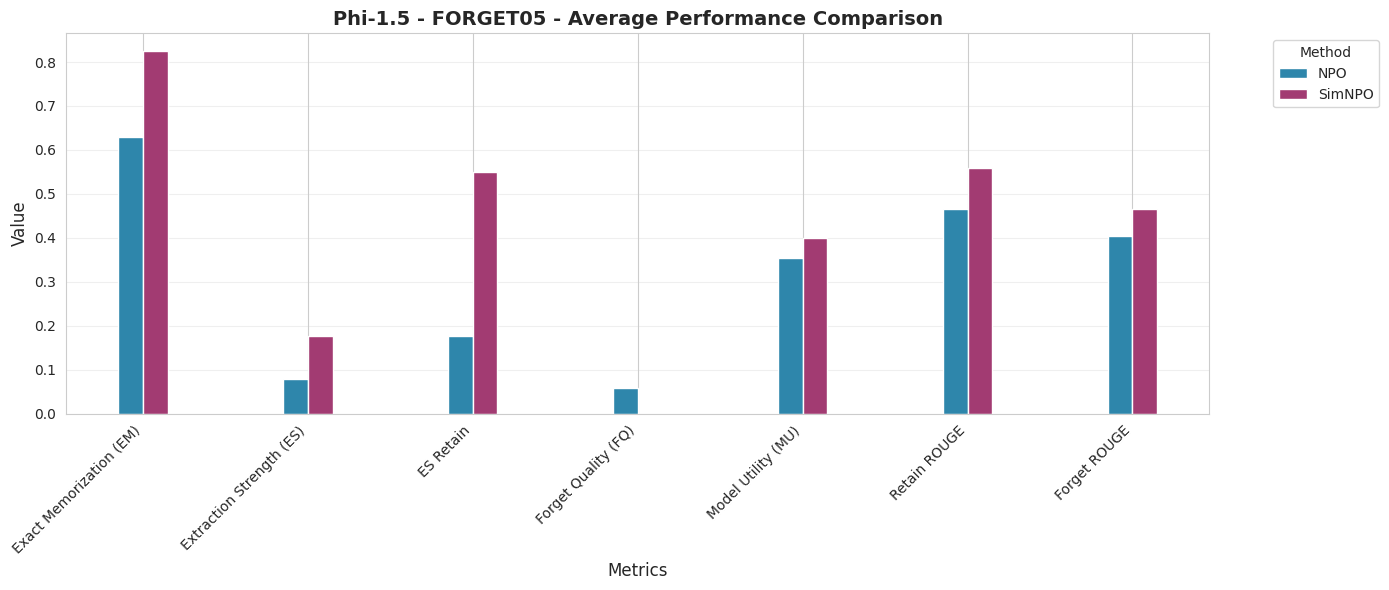


Average metric performance per method - FORGET10
        exact_memorization  extraction_strength  extraction_strength_retain  \
method                                                                        
NPO                 0.6483               0.0777                      0.2175   
SimNPO              0.8068               0.1405                      0.4784   

        forget_quality  model_utility  retain_Q_A_ROUGE  forget_Q_A_ROUGE  
method                                                                     
NPO             0.0259         0.3737            0.4693            0.3998  
SimNPO          0.0000         0.3960            0.5490            0.4455  


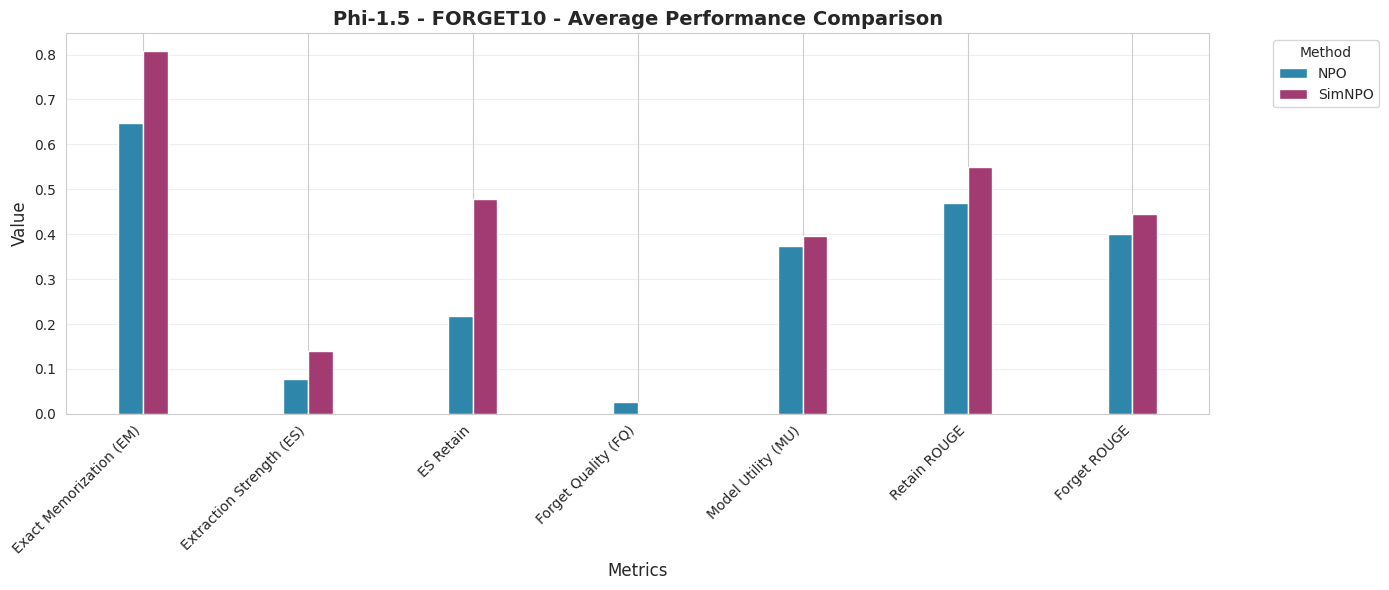

In [11]:
# Calculate average performance for each method and forget set
for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set]
    method_performance = forget_df.groupby('method')[metrics].mean()
    
    print(f"\n{'='*60}")
    print(f"Average metric performance per method - {forget_set.upper()}")
    print('='*60)
    print(method_performance.round(4))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(metrics))
    width = 0.15
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
    
    for i, method in enumerate(method_performance.index):
        offset = (i - len(method_performance) / 2 + 0.5) * width
        values = method_performance.loc[method, metrics].values
        ax.bar(x + offset, values, width, label=method, color=colors[i % len(colors)])
    
    ax.set_xlabel('Metrics', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_title(f'{model_name} - {forget_set.upper()} - Average Performance Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([metric_labels[m] for m in metrics], rotation=45, ha='right')
    ax.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    # plt.savefig(f'/cnz/data/project/my-open-unlearning/notebooks/method_comparison_{forget_set}.png', 
    #            dpi=300, bbox_inches='tight')
    plt.show()

## 7. Composite Score Analysis (ES + MU Only)

Best configuration selection based on:
- **50% Model Utility (MU)** - Higher is better
- **50% Extraction Strength (ES)** - Lower is better

In [12]:
# Create composite score: normalize metrics and weight them
# SIMPLIFIED: Using only ES and MU
# Higher is better: model_utility
# Lower is better: extraction_strength
from sklearn.preprocessing import MinMaxScaler

# Process each forget set separately
for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    
    if len(forget_df) == 0:
        continue
    
    scaler = MinMaxScaler()
    
    # For metrics where higher is better
    forget_df['model_utility_norm'] = scaler.fit_transform(forget_df[['model_utility']])
    
    # For metrics where lower is better (invert)
    forget_df['extraction_strength_norm'] = 1 - scaler.fit_transform(forget_df[['extraction_strength']])
    
    # Calculate composite score using only ES and MU
    # ES: 50% weight (lower is better, so we use inverted normalized value)
    # MU: 50% weight (higher is better)
    forget_df['composite_score'] = (
        forget_df['model_utility_norm'] * 0.5 + 
        forget_df['extraction_strength_norm'] * 0.5
    )
    
    # Update main dataframe
    df.loc[df['forget_set'] == forget_set, 'composite_score'] = forget_df['composite_score'].values
    
    # Display Top 10 configurations
    top_configs = forget_df.nlargest(10, 'composite_score')[[
        'dir_name', 'method', 'forget_set', 'beta', 'gamma', 'composite_score',
        'model_utility', 'extraction_strength'
    ]]
    
    print(f"\n{'='*80}")
    print(f"Top 10 Configurations by Composite Score (ES+MU) - {forget_set.upper()}")
    print('='*80)
    print(f"Criteria: 50% Model Utility (higher is better) + 50% Extraction Strength (lower is better)")
    print(top_configs.to_string(index=False))


Top 10 Configurations by Composite Score (ES+MU) - FORGET05
Criteria: 50% Model Utility (higher is better) + 50% Extraction Strength (lower is better)
                                          dir_name method forget_set  beta  gamma  composite_score  model_utility  extraction_strength
 tofu_phi-1_5_forget05_NPO_beta0.2_gamma0.2_epoch5    NPO   forget05  0.20    0.2         0.824923       0.393118             0.096690
 tofu_phi-1_5_forget05_NPO_beta0.1_gamma0.2_epoch5    NPO   forget05  0.10    0.2         0.821119       0.374849             0.073016
tofu_phi-1_5_forget05_NPO_beta0.15_gamma0.2_epoch5    NPO   forget05  0.15    0.2         0.801748       0.384382             0.092539
 tofu_phi-1_5_forget05_NPO_beta0.2_gamma0.3_epoch5    NPO   forget05  0.20    0.3         0.779608       0.382868             0.097905
tofu_phi-1_5_forget05_NPO_beta0.15_gamma0.3_epoch5    NPO   forget05  0.15    0.3         0.770929       0.372929             0.087244
 tofu_phi-1_5_forget05_NPO_beta0.1_gam

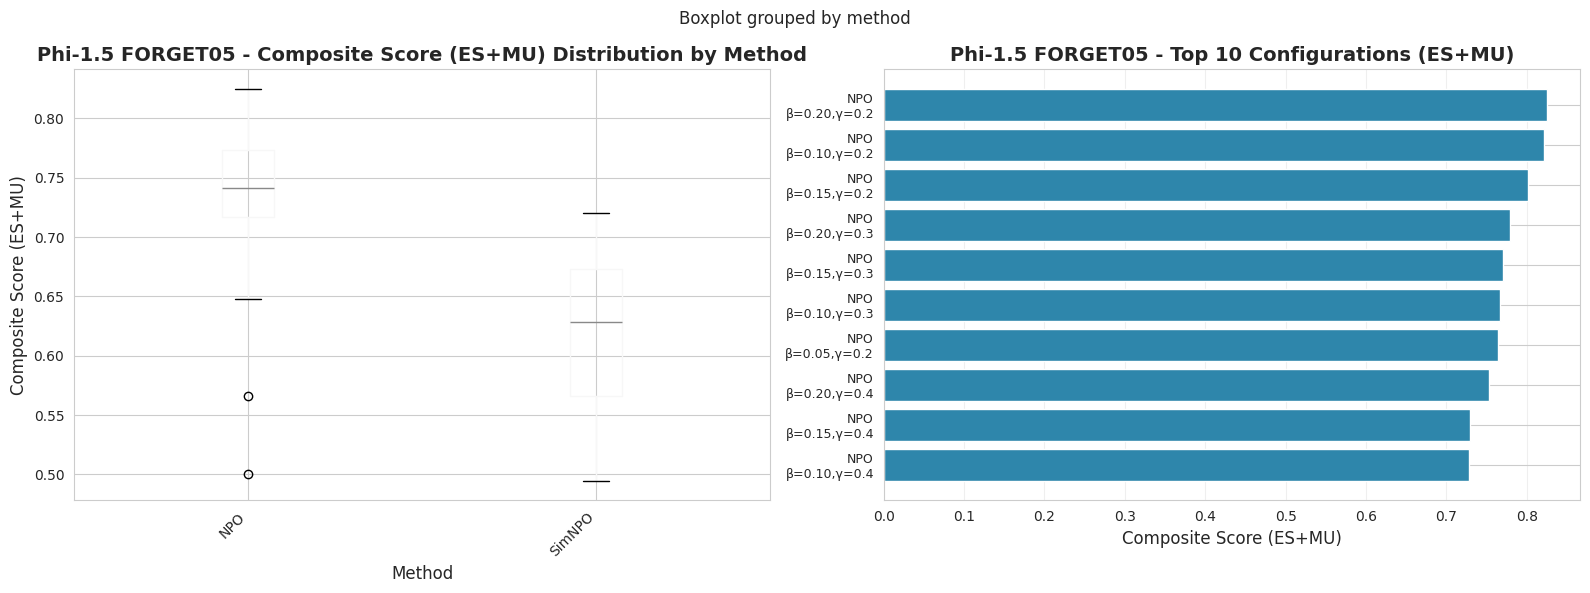

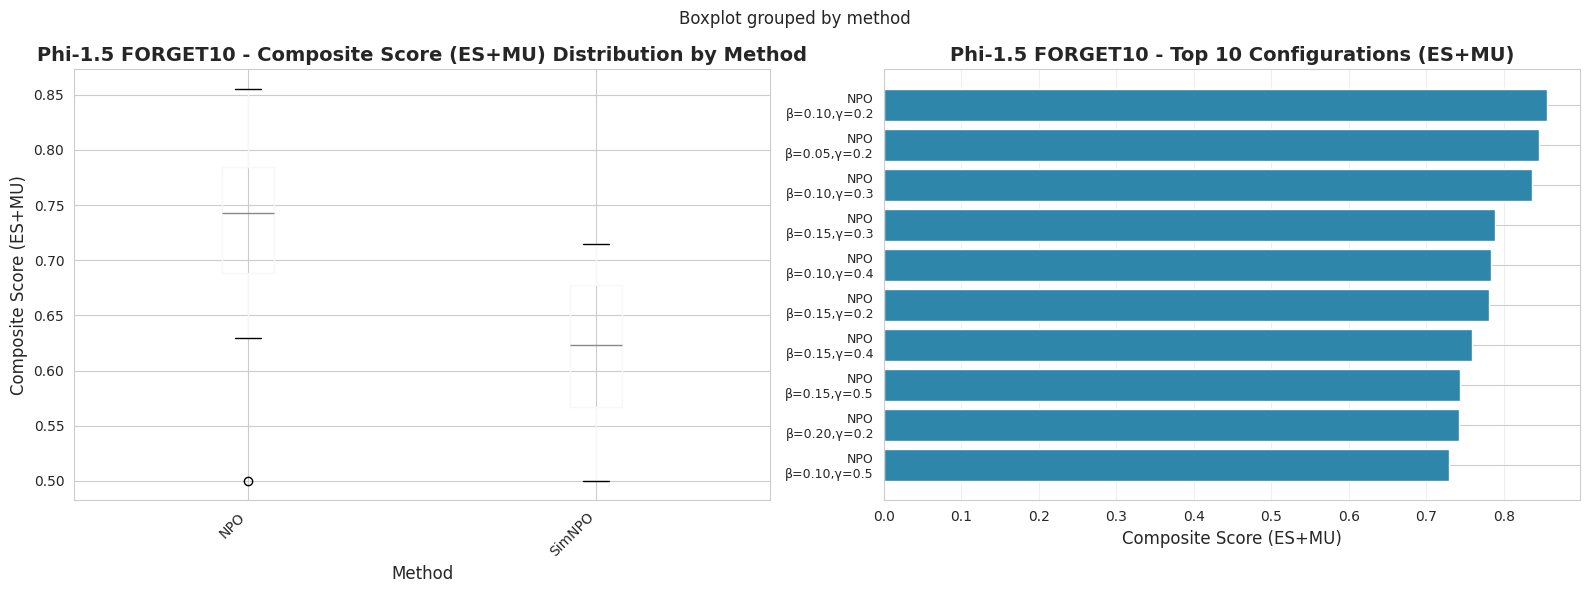

In [13]:
# Visualize composite score distribution for each forget set
for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    
    if len(forget_df) == 0:
        continue
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Boxplot by method
    forget_df.boxplot(column='composite_score', by='method', ax=axes[0])
    axes[0].set_title(f'{model_name} {forget_set.upper()} - Composite Score (ES+MU) Distribution by Method', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Method', fontsize=12)
    axes[0].set_ylabel('Composite Score (ES+MU)', fontsize=12)
    plt.sca(axes[0])
    plt.xticks(rotation=45, ha='right')
    
    # Top 10 configurations bar chart
    top_10 = forget_df.nlargest(10, 'composite_score')
    y_pos = range(len(top_10))
    axes[1].barh(y_pos, top_10['composite_score'], color='#2E86AB')
    axes[1].set_yticks(y_pos)
    
    # Create labels with method and hyperparameters
    labels = []
    for _, row in top_10.iterrows():
        label = f"{row['method']}"
        if 'beta' in row and pd.notna(row['beta']):
            label += f"\nβ={row['beta']:.2f}"
        if 'gamma' in row and pd.notna(row['gamma']):
            label += f",γ={row['gamma']:.1f}"
        labels.append(label)
    
    axes[1].set_yticklabels(labels, fontsize=9)
    axes[1].set_xlabel('Composite Score (ES+MU)', fontsize=12)
    axes[1].set_title(f'{model_name} {forget_set.upper()} - Top 10 Configurations (ES+MU)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='x')
    axes[1].invert_yaxis()  # Best on top
    
    plt.tight_layout()
    # plt.savefig(f'/cnz/data/project/my-open-unlearning/notebooks/composite_score_{forget_set}.png', 
    #            dpi=300, bbox_inches='tight')
    plt.show()

## 9. Export Detailed Results

In [14]:
# Create comprehensive comparison of best vs worst configurations
for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    
    if len(forget_df) == 0:
        continue
    
    print(f"\n{'='*100}")
    print(f"BEST vs WORST COMPARISON - {forget_set.upper()}")
    print('='*100)
    
    for method in methods:
        method_df = forget_df[forget_df['method'] == method].copy()
        
        if len(method_df) < 2:
            continue
        
        best = method_df.nlargest(1, 'composite_score').iloc[0]
        worst = method_df.nsmallest(1, 'composite_score').iloc[0]
        
        print(f"\n{method} Method:")
        print("-" * 80)
        
        # Hyperparameters comparison
        print("  Hyperparameters:")
        if 'beta' in best and pd.notna(best['beta']):
            print(f"    Beta:  Best={best['beta']:.3f}  |  Worst={worst['beta']:.3f}")
        if 'gamma' in best and pd.notna(best['gamma']):
            print(f"    Gamma: Best={best['gamma']:.3f}  |  Worst={worst['gamma']:.3f}")
        
        print(f"\n  Metrics Comparison (Primary: ES & MU):")
        print(f"    {'Metric':<30s} | {'Best':>10s} | {'Worst':>10s} | {'Δ':>10s} | {'Goal':>5s}")
        print(f"    {'-'*30} | {'-'*10} | {'-'*10} | {'-'*10} | {'-'*5}")
        
        # Show ES and MU first
        priority_metrics = ['extraction_strength', 'model_utility']
        other_metrics = [m for m in metrics if m not in priority_metrics]
        
        for m in priority_metrics + other_metrics:
            delta = best[m] - worst[m]
            goal = "↑" if m in ['forget_quality', 'model_utility', 'retain_Q_A_ROUGE', 'extraction_strength_retain'] else "↓"
            marker = " ***" if m in priority_metrics else ""
            print(f"    {metric_labels[m]:<30s} | {best[m]:>10.4f} | {worst[m]:>10.4f} | {delta:>+10.4f} | {goal:>5s}{marker}")
        
        print(f"\n  Composite Score (ES+MU): {best['composite_score']:.4f} (best) vs {worst['composite_score']:.4f} (worst)")
        print(f"  Improvement: {((best['composite_score'] - worst['composite_score']) / worst['composite_score'] * 100):+.2f}%")


BEST vs WORST COMPARISON - FORGET05

NPO Method:
--------------------------------------------------------------------------------
  Hyperparameters:
    Beta:  Best=0.200  |  Worst=0.050
    Gamma: Best=0.200  |  Worst=0.500

  Metrics Comparison (Primary: ES & MU):
    Metric                         |       Best |      Worst |          Δ |  Goal
    ------------------------------ | ---------- | ---------- | ---------- | -----
    Extraction Strength (ES)       |     0.0967 |     0.0556 |    +0.0411 |     ↓ ***
    Model Utility (MU)             |     0.3931 |     0.2832 |    +0.1100 |     ↑ ***
    Exact Memorization (EM)        |     0.7118 |     0.4945 |    +0.2173 |     ↓
    ES Retain                      |     0.3598 |     0.0843 |    +0.2756 |     ↑
    Forget Quality (FQ)            |     0.0030 |     0.0021 |    +0.0009 |     ↑
    Retain ROUGE                   |     0.4986 |     0.4070 |    +0.0915 |     ↑
    Forget ROUGE                   |     0.4084 |     0.3382 |    +0

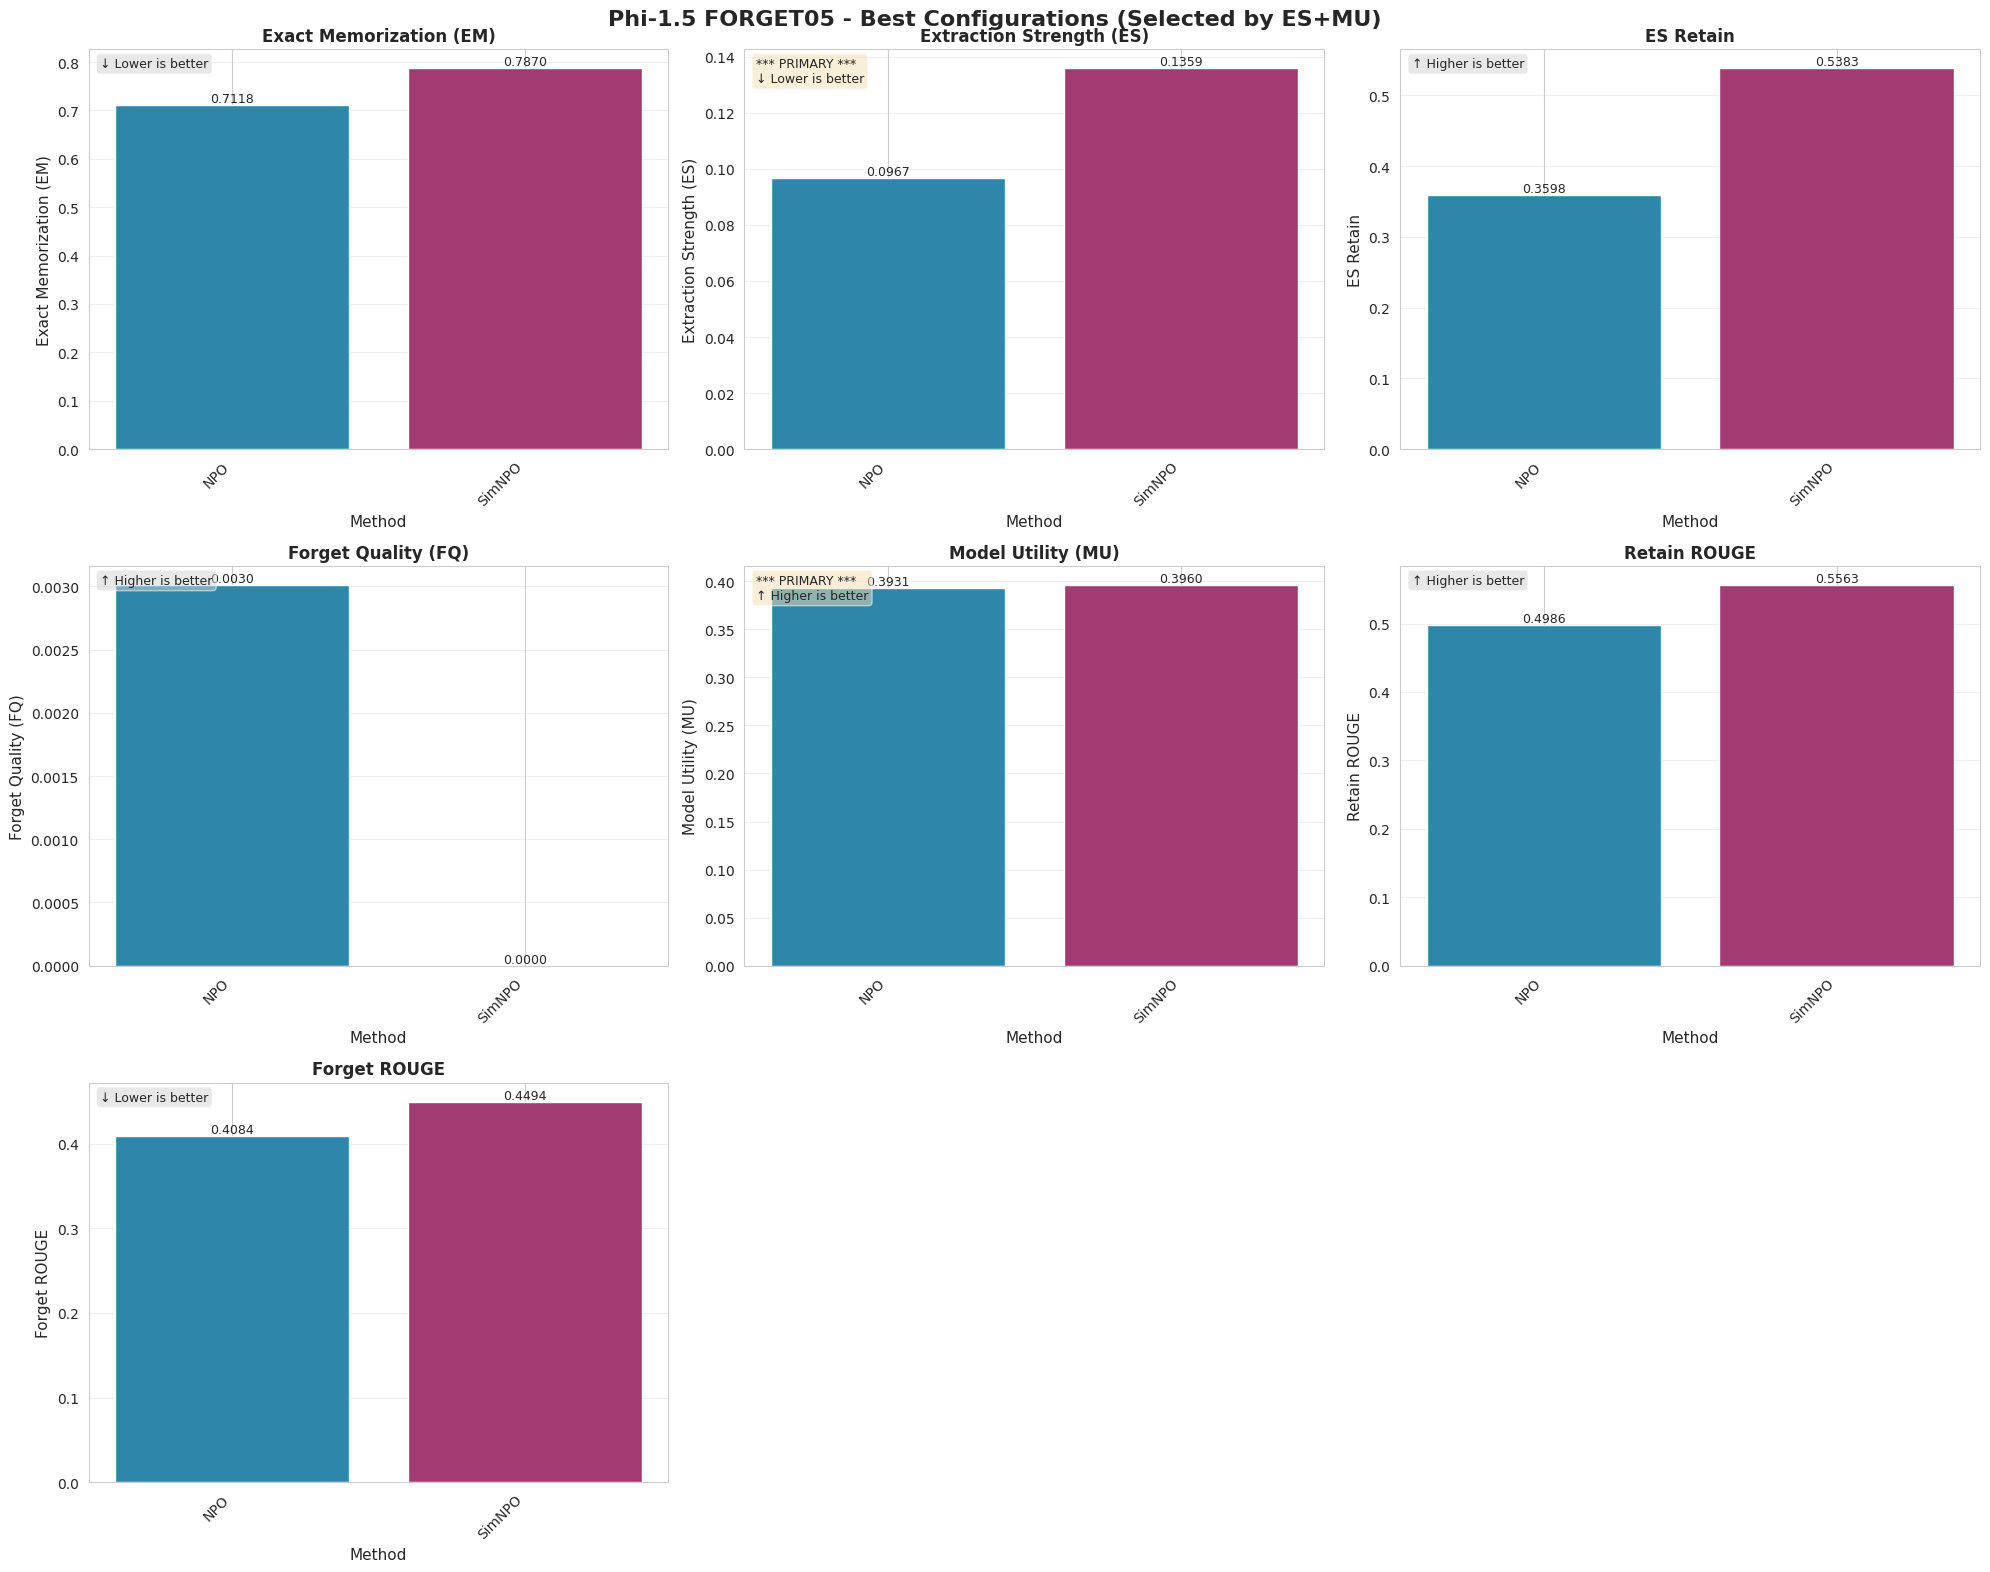


Phi-1.5 - BEST CONFIGURATIONS SUMMARY (Selected by ES+MU) - FORGET05
method  beta  gamma  composite_score  model_utility  extraction_strength  extraction_strength_retain  forget_quality  retain_Q_A_ROUGE  forget_Q_A_ROUGE  exact_memorization
   NPO   0.2    0.2         0.824923       0.393118             0.096690                    0.359841    3.009847e-03          0.498572          0.408434             0.71181
SimNPO   2.0    0.2         0.719975       0.396035             0.135906                    0.538316    8.114130e-08          0.556304          0.449440             0.78704


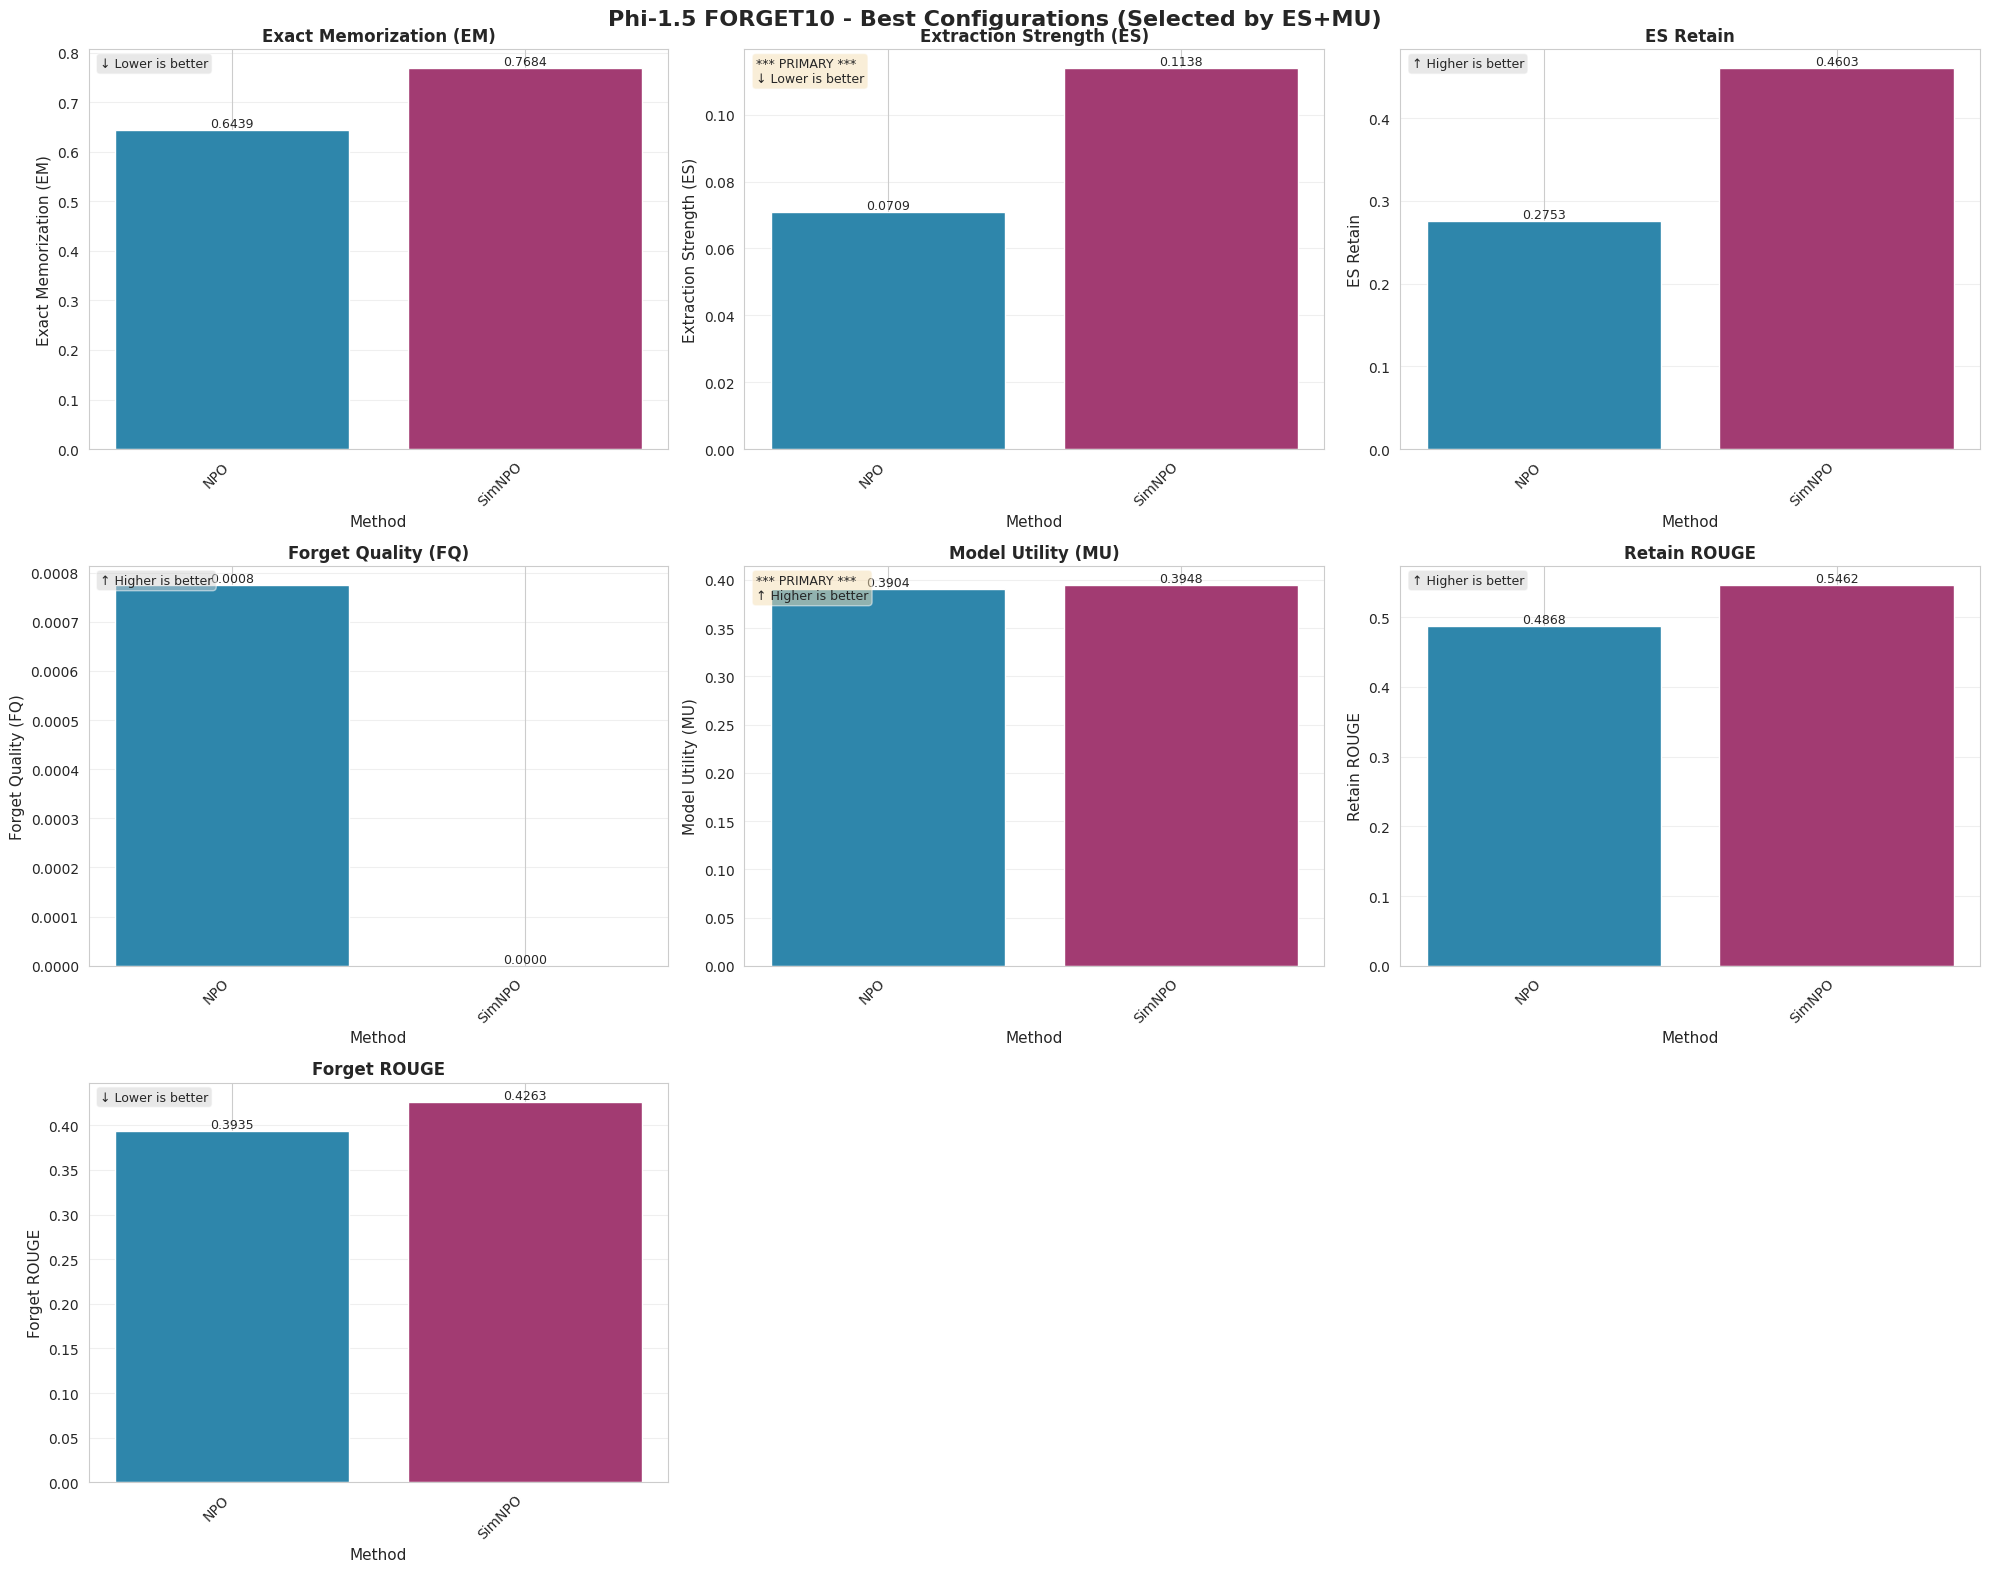


Phi-1.5 - BEST CONFIGURATIONS SUMMARY (Selected by ES+MU) - FORGET10
method  beta  gamma  composite_score  model_utility  extraction_strength  extraction_strength_retain  forget_quality  retain_Q_A_ROUGE  forget_Q_A_ROUGE  exact_memorization
   NPO   0.1    0.2         0.855318       0.390394             0.070886                    0.275307    7.748993e-04          0.486830          0.393497            0.643862
SimNPO   2.0    0.2         0.714819       0.394761             0.113831                    0.460315    7.832453e-12          0.546158          0.426331            0.768357


In [15]:
# Visualize best configurations for each method
for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    
    if len(forget_df) == 0:
        continue
    
    # Get best config for each method
    best_configs = []
    for method in methods:
        method_df = forget_df[forget_df['method'] == method].copy()
        if len(method_df) > 0:
            best = method_df.nlargest(1, 'composite_score').iloc[0]
            best_configs.append(best)
    
    if len(best_configs) == 0:
        continue
    
    best_df = pd.DataFrame(best_configs)
    
    # Create radar chart for best configurations
    fig, axes = plt.subplots(3, 3, figsize=(20, 16))
    axes = axes.flatten()
    fig.suptitle(f'{model_name} {forget_set.upper()} - Best Configurations (Selected by ES+MU)', 
                 fontsize=16, fontweight='bold')
    
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        x_pos = np.arange(len(best_df))
        bars = ax.bar(x_pos, best_df[metric], color=colors[:len(best_df)])
        
        # Add value labels on bars
        for i, (bar, val) in enumerate(zip(bars, best_df[metric])):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.4f}',
                   ha='center', va='bottom', fontsize=9)
        
        ax.set_xlabel('Method', fontsize=11)
        ax.set_ylabel(metric_labels[metric], fontsize=11)
        ax.set_title(metric_labels[metric], fontsize=12, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(best_df['method'], rotation=45, ha='right')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add indicator for optimization direction, highlight ES and MU
        if metric in ['extraction_strength', 'model_utility']:
            indicator = "*** PRIMARY ***\n"
        else:
            indicator = ""
        
        direction = "↓ Lower is better" if metric in ['exact_memorization', 'extraction_strength', 'forget_Q_A_ROUGE'] else "↑ Higher is better"
        ax.text(0.02, 0.98, indicator + direction, transform=ax.transAxes,
               fontsize=9, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat' if metric in ['extraction_strength', 'model_utility'] else 'lightgray', alpha=0.5))
    
    # Hide extra subplots
    for idx in range(len(metrics), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print(f"\n{'='*100}")
    print(f"{model_name} - BEST CONFIGURATIONS SUMMARY (Selected by ES+MU) - {forget_set.upper()}")
    print('='*100)
    
    summary_cols = ['method', 'beta', 'gamma', 'composite_score', 
                   'model_utility', 'extraction_strength', 'extraction_strength_retain',
                   'forget_quality', 'retain_Q_A_ROUGE', 
                   'forget_Q_A_ROUGE', 'exact_memorization']
    print(best_df[summary_cols].to_string(index=False))

In [16]:
# Analyze best hyperparameters for each method
# Use composite score (ES+MU only) already calculated above

for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    
    if len(forget_df) == 0:
        continue
    
    print(f"\n{'='*100}")
    print(f"{model_name} - BEST HYPERPARAMETERS ANALYSIS (Based on ES+MU) - {forget_set.upper()}")
    print('='*100)
    print("Selection Criteria: 50% Model Utility (↑) + 50% Extraction Strength (↓)")
    
    for method in methods:
        method_df = forget_df[forget_df['method'] == method].copy()
        
        if len(method_df) == 0:
            continue
        
        # Find the best configuration based on composite score
        best_config = method_df.nlargest(1, 'composite_score').iloc[0]
        
        print(f"\n{method} Method - Best Configuration:")
        print("-" * 80)
        
        # Display hyperparameters
        if pd.notna(best_config.get('beta')):
            print(f"  Beta (β): {best_config['beta']:.3f}")
        if pd.notna(best_config.get('gamma')):
            print(f"  Gamma (γ): {best_config['gamma']:.3f}")
        if pd.notna(best_config.get('alpha')):
            print(f"  Alpha (α): {best_config['alpha']:.3f}")
        if pd.notna(best_config.get('epoch')):
            print(f"  Epochs: {best_config['epoch']}")
        
        print(f"\n  Performance Metrics:")
        print(f"    Composite Score (ES+MU): {best_config['composite_score']:.4f}")
        print(f"    >>> Model Utility (MU):         {best_config['model_utility']:.4f}  ↑ ***PRIMARY***")
        print(f"    >>> Extraction Strength (ES):   {best_config['extraction_strength']:.4f}  ↓ ***PRIMARY***")
        print(f"    ES Retain:                      {best_config['extraction_strength_retain']:.4f}  ↓")
        print(f"    Forget Quality (FQ):            {best_config['forget_quality']:.6f}  ↑")
        print(f"    Retain ROUGE:                   {best_config['retain_Q_A_ROUGE']:.4f}  ↑")
        print(f"    Forget ROUGE:                   {best_config['forget_Q_A_ROUGE']:.4f}  ↓")
        print(f"    Exact Memorization (EM):        {best_config['exact_memorization']:.4f}  ↓")
        
        print(f"\n  Model Directory: {best_config['dir_name']}")
        
        # Show comparison with average
        method_avg = method_df[metrics].mean()
        print(f"\n  Improvement vs Method Average:")
        
        improvements = {}
        # Show ES and MU first (primary metrics)
        print(f"    {'PRIMARY METRICS:':<30s}")
        for m in ['model_utility', 'extraction_strength']:
            if m in method_avg:
                if m == 'model_utility':
                    improvement = ((best_config[m] - method_avg[m]) / method_avg[m] * 100)
                else:  # extraction_strength - lower is better
                    improvement = ((method_avg[m] - best_config[m]) / method_avg[m] * 100)
                improvements[m] = improvement
                print(f"    {metric_labels[m]:30s}: {improvement:+6.2f}%")
        
        print(f"\n    {'SECONDARY METRICS:':<30s}")
        # For metrics where higher is better
        for m in ['forget_quality', 'retain_Q_A_ROUGE', 'extraction_strength_retain']:
            if m in method_avg:
                improvement = ((best_config[m] - method_avg[m]) / method_avg[m] * 100)
                improvements[m] = improvement
                print(f"    {metric_labels[m]:30s}: {improvement:+6.2f}%")
        
        # For metrics where lower is better
        for m in ['exact_memorization', 'forget_Q_A_ROUGE']:
            if m in method_avg:
                improvement = ((method_avg[m] - best_config[m]) / method_avg[m] * 100)
                improvements[m] = improvement
                print(f"    {metric_labels[m]:30s}: {improvement:+6.2f}%")


Phi-1.5 - BEST HYPERPARAMETERS ANALYSIS (Based on ES+MU) - FORGET05
Selection Criteria: 50% Model Utility (↑) + 50% Extraction Strength (↓)

NPO Method - Best Configuration:
--------------------------------------------------------------------------------
  Beta (β): 0.200
  Gamma (γ): 0.200
  Epochs: 5

  Performance Metrics:
    Composite Score (ES+MU): 0.8249
    >>> Model Utility (MU):         0.3931  ↑ ***PRIMARY***
    >>> Extraction Strength (ES):   0.0967  ↓ ***PRIMARY***
    ES Retain:                      0.3598  ↓
    Forget Quality (FQ):            0.003010  ↑
    Retain ROUGE:                   0.4986  ↑
    Forget ROUGE:                   0.4084  ↓
    Exact Memorization (EM):        0.7118  ↓

  Model Directory: tofu_phi-1_5_forget05_NPO_beta0.2_gamma0.2_epoch5

  Improvement vs Method Average:
    PRIMARY METRICS:              
    Model Utility (MU)            : +10.67%
    Extraction Strength (ES)      : -23.31%

    SECONDARY METRICS:            
    Forget Quality (

## 8. Best Hyperparameter Analysis

Find the best hyperparameters for each method by balancing all metrics:
- Minimize: EM, ES, Forget ROUGE
- Maximize: Retain ROUGE, MU, FQ

In [17]:
# Save complete analysis results to CSV
output_csv = '/cnz/data/project/my-open-unlearning/notebooks/phi_unlearn_analysis_results.csv'
df.to_csv(output_csv, index=False)
print(f"Complete analysis results saved to: {output_csv}")

# Save best configurations for each method and forget set
best_configs_all = []
for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    for method in methods:
        method_df = forget_df[forget_df['method'] == method].copy()
        if len(method_df) > 0:
            best = method_df.nlargest(1, 'composite_score')
            best_configs_all.append(best)

if best_configs_all:
    best_configs_df = pd.concat(best_configs_all)
    best_configs_df.to_csv('/cnz/data/project/my-open-unlearning/notebooks/phi_best_configurations.csv', index=False)
    print("Best configurations per method saved to: phi_best_configurations.csv")

print("\nAnalysis complete!")

Complete analysis results saved to: /cnz/data/project/my-open-unlearning/notebooks/phi_unlearn_analysis_results.csv
Best configurations per method saved to: phi_best_configurations.csv

Analysis complete!



Phi-1.5 - BEST HYPERPARAMETERS BY ES GAP (ES_Retain - ES_Forget) - FORGET05
Selection Criteria: Maximize (ES_Retain - ES_Forget)
  - ES_Retain: Extraction strength on retain data (higher is better)
  - ES_Forget: Extraction strength on forget data (lower is better)
  - Larger gap indicates better unlearning with good retain performance

NPO Method - Best Configuration:
--------------------------------------------------------------------------------
  Beta (β): 0.200
  Gamma (γ): 0.200
  Epochs: 5

  ES Gap Analysis:
    ES Gap (ES_Retain - ES_Forget):  0.2632  *** TARGET METRIC ***
    └─ ES Retain:                     0.3598  ↑
    └─ ES Forget:                     0.0967  ↓

  Other Performance Metrics:
    Model Utility (MU):               0.3931  ↑
    Forget Quality (FQ):              0.003010  ↑
    Retain ROUGE:                     0.4986  ↑
    Forget ROUGE:                     0.4084  ↓
    Exact Memorization (EM):          0.7118  ↓
    Composite Score (ES+MU):          0.82

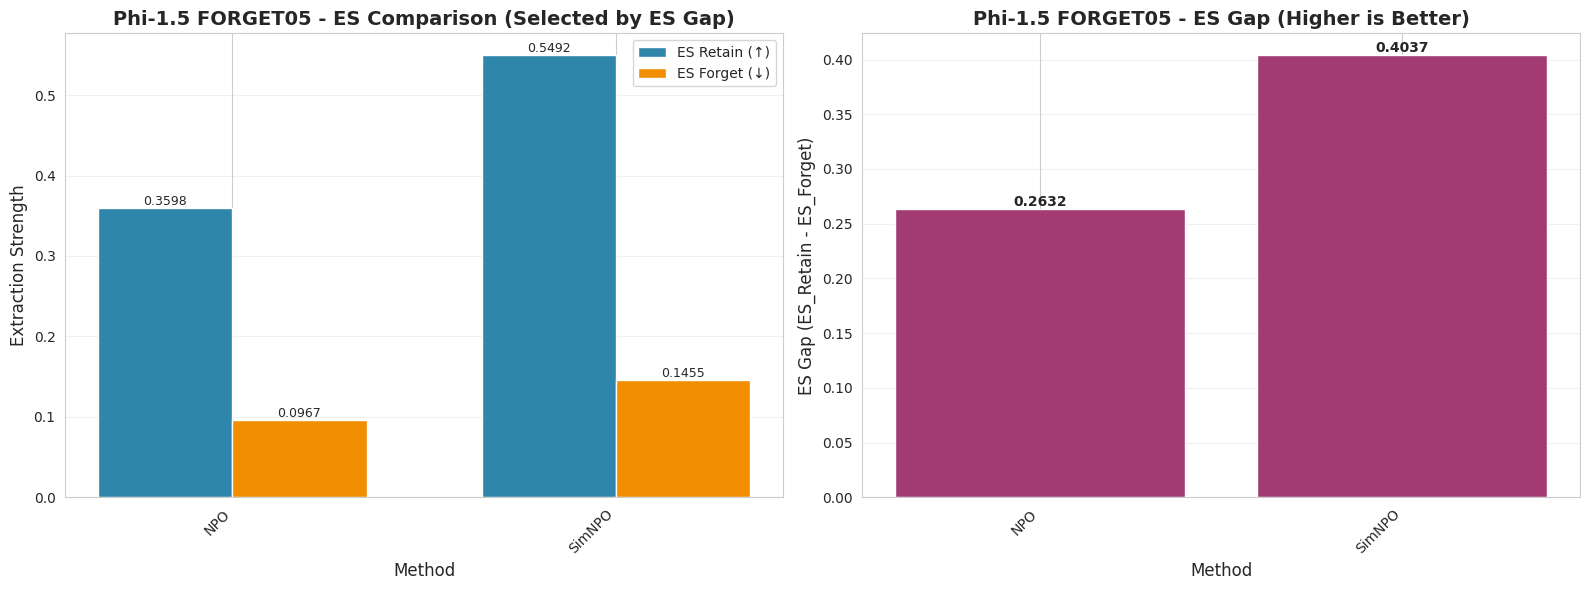


Phi-1.5 - BEST CONFIGURATIONS BY ES GAP - FORGET05
method  beta  gamma   es_gap  extraction_strength_retain  extraction_strength  model_utility  forget_quality  composite_score
   NPO   0.2    0.2 0.263151                    0.359841             0.096690       0.393118    3.009847e-03         0.824923
SimNPO   2.5    0.2 0.403746                    0.549224             0.145478       0.399020    3.602473e-09         0.703607


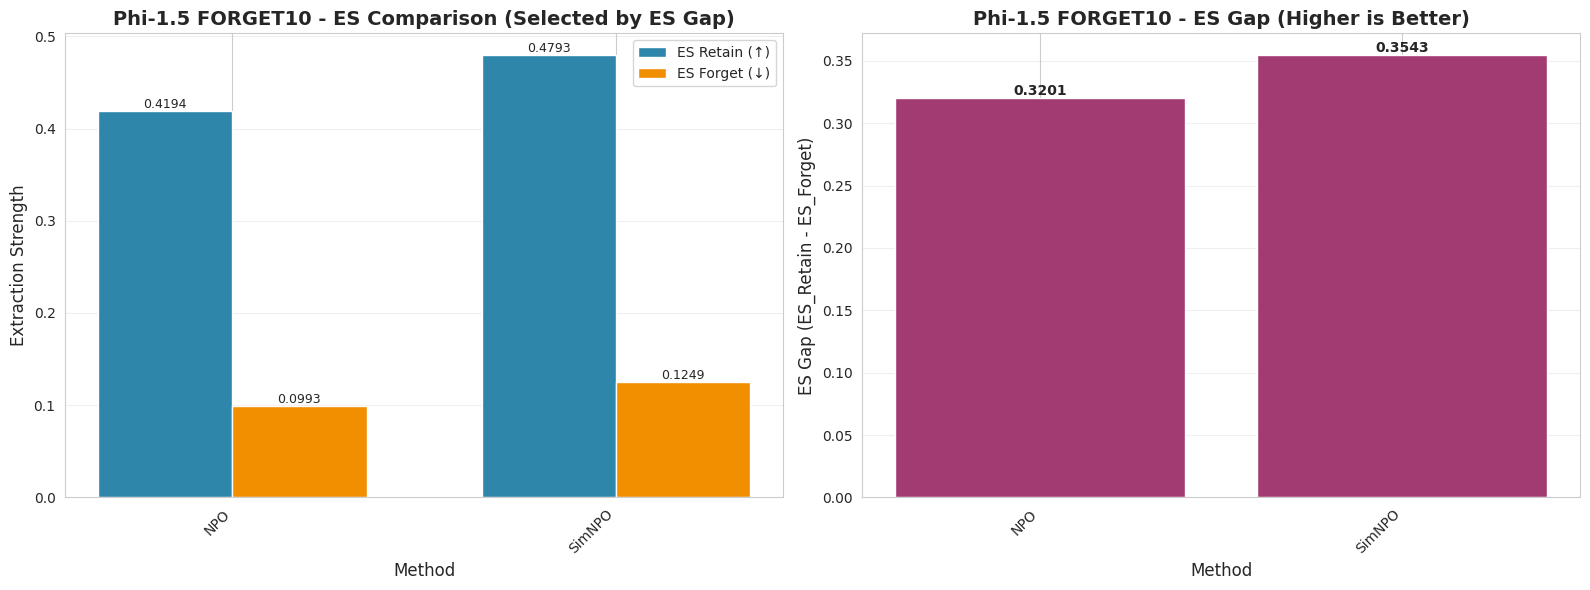


Phi-1.5 - BEST CONFIGURATIONS BY ES GAP - FORGET10
method  beta  gamma   es_gap  extraction_strength_retain  extraction_strength  model_utility  forget_quality  composite_score
   NPO  0.20  0.200 0.320143                    0.419413             0.099270       0.389615    1.652551e-08         0.741906
SimNPO  2.25  0.175 0.354346                    0.479273             0.124927       0.395790    2.734462e-12         0.677960

Analysis based on ES Gap complete!


In [18]:
# Calculate ES gap (ES_Retain - ES_Forget) for each configuration
df['es_gap'] = df['extraction_strength_retain'] - df['extraction_strength']

for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    
    if len(forget_df) == 0:
        continue
    
    print(f"\n{'='*100}")
    print(f"{model_name} - BEST HYPERPARAMETERS BY ES GAP (ES_Retain - ES_Forget) - {forget_set.upper()}")
    print('='*100)
    print("Selection Criteria: Maximize (ES_Retain - ES_Forget)")
    print("  - ES_Retain: Extraction strength on retain data (higher is better)")
    print("  - ES_Forget: Extraction strength on forget data (lower is better)")
    print("  - Larger gap indicates better unlearning with good retain performance")
    
    for method in methods:
        method_df = forget_df[forget_df['method'] == method].copy()
        
        if len(method_df) == 0:
            continue
        
        # Find the best configuration based on ES gap
        best_config = method_df.nlargest(1, 'es_gap').iloc[0]
        
        print(f"\n{method} Method - Best Configuration:")
        print("-" * 80)
        
        # Display hyperparameters
        if pd.notna(best_config.get('beta')):
            print(f"  Beta (β): {best_config['beta']:.3f}")
        if pd.notna(best_config.get('gamma')):
            print(f"  Gamma (γ): {best_config['gamma']:.3f}")
        if pd.notna(best_config.get('alpha')):
            print(f"  Alpha (α): {best_config['alpha']:.3f}")
        if pd.notna(best_config.get('epoch')):
            print(f"  Epochs: {best_config['epoch']}")
        
        print(f"\n  ES Gap Analysis:")
        print(f"    ES Gap (ES_Retain - ES_Forget):  {best_config['es_gap']:.4f}  *** TARGET METRIC ***")
        print(f"    └─ ES Retain:                     {best_config['extraction_strength_retain']:.4f}  ↑")
        print(f"    └─ ES Forget:                     {best_config['extraction_strength']:.4f}  ↓")
        
        print(f"\n  Other Performance Metrics:")
        print(f"    Model Utility (MU):               {best_config['model_utility']:.4f}  ↑")
        print(f"    Forget Quality (FQ):              {best_config['forget_quality']:.6f}  ↑")
        print(f"    Retain ROUGE:                     {best_config['retain_Q_A_ROUGE']:.4f}  ↑")
        print(f"    Forget ROUGE:                     {best_config['forget_Q_A_ROUGE']:.4f}  ↓")
        print(f"    Exact Memorization (EM):          {best_config['exact_memorization']:.4f}  ↓")
        print(f"    Composite Score (ES+MU):          {best_config['composite_score']:.4f}")
        
        print(f"\n  Model Directory: {best_config['dir_name']}")
        
        # Show comparison with method average
        method_avg_gap = method_df['es_gap'].mean()
        improvement = ((best_config['es_gap'] - method_avg_gap) / abs(method_avg_gap) * 100) if method_avg_gap != 0 else 0
        print(f"\n  ES Gap Improvement vs Method Average:")
        print(f"    Method Average ES Gap:  {method_avg_gap:.4f}")
        print(f"    Best Config ES Gap:     {best_config['es_gap']:.4f}")
        print(f"    Improvement:            {improvement:+6.2f}%")

# Visualize ES gap for best configurations
for forget_set in forget_sets:
    forget_df = df[df['forget_set'] == forget_set].copy()
    
    if len(forget_df) == 0:
        continue
    
    # Get best config for each method based on ES gap
    best_configs_gap = []
    for method in methods:
        method_df = forget_df[forget_df['method'] == method].copy()
        if len(method_df) > 0:
            best = method_df.nlargest(1, 'es_gap').iloc[0]
            best_configs_gap.append(best)
    
    if len(best_configs_gap) == 0:
        continue
    
    best_gap_df = pd.DataFrame(best_configs_gap)
    
    # Create comparison visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: ES Retain vs ES Forget comparison
    x_pos = np.arange(len(best_gap_df))
    width = 0.35
    
    ax1 = axes[0]
    bars1 = ax1.bar(x_pos - width/2, best_gap_df['extraction_strength_retain'], 
                    width, label='ES Retain (↑)', color='#2E86AB')
    bars2 = ax1.bar(x_pos + width/2, best_gap_df['extraction_strength'], 
                    width, label='ES Forget (↓)', color='#F18F01')
    
    ax1.set_xlabel('Method', fontsize=12)
    ax1.set_ylabel('Extraction Strength', fontsize=12)
    ax1.set_title(f'{model_name} {forget_set.upper()} - ES Comparison (Selected by ES Gap)', 
                  fontsize=14, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(best_gap_df['method'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    
    # Plot 2: ES Gap bar chart
    ax2 = axes[1]
    bars_gap = ax2.bar(x_pos, best_gap_df['es_gap'], color='#A23B72')
    
    ax2.set_xlabel('Method', fontsize=12)
    ax2.set_ylabel('ES Gap (ES_Retain - ES_Forget)', fontsize=12)
    ax2.set_title(f'{model_name} {forget_set.upper()} - ES Gap (Higher is Better)', 
                  fontsize=14, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(best_gap_df['method'], rotation=45, ha='right')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar in bars_gap:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print(f"\n{'='*100}")
    print(f"{model_name} - BEST CONFIGURATIONS BY ES GAP - {forget_set.upper()}")
    print('='*100)
    
    summary_cols = ['method', 'beta', 'gamma', 'es_gap',
                   'extraction_strength_retain', 'extraction_strength',
                   'model_utility', 'forget_quality', 'composite_score']
    print(best_gap_df[summary_cols].to_string(index=False))

print("\n" + "="*100)
print("Analysis based on ES Gap complete!")
print("="*100)

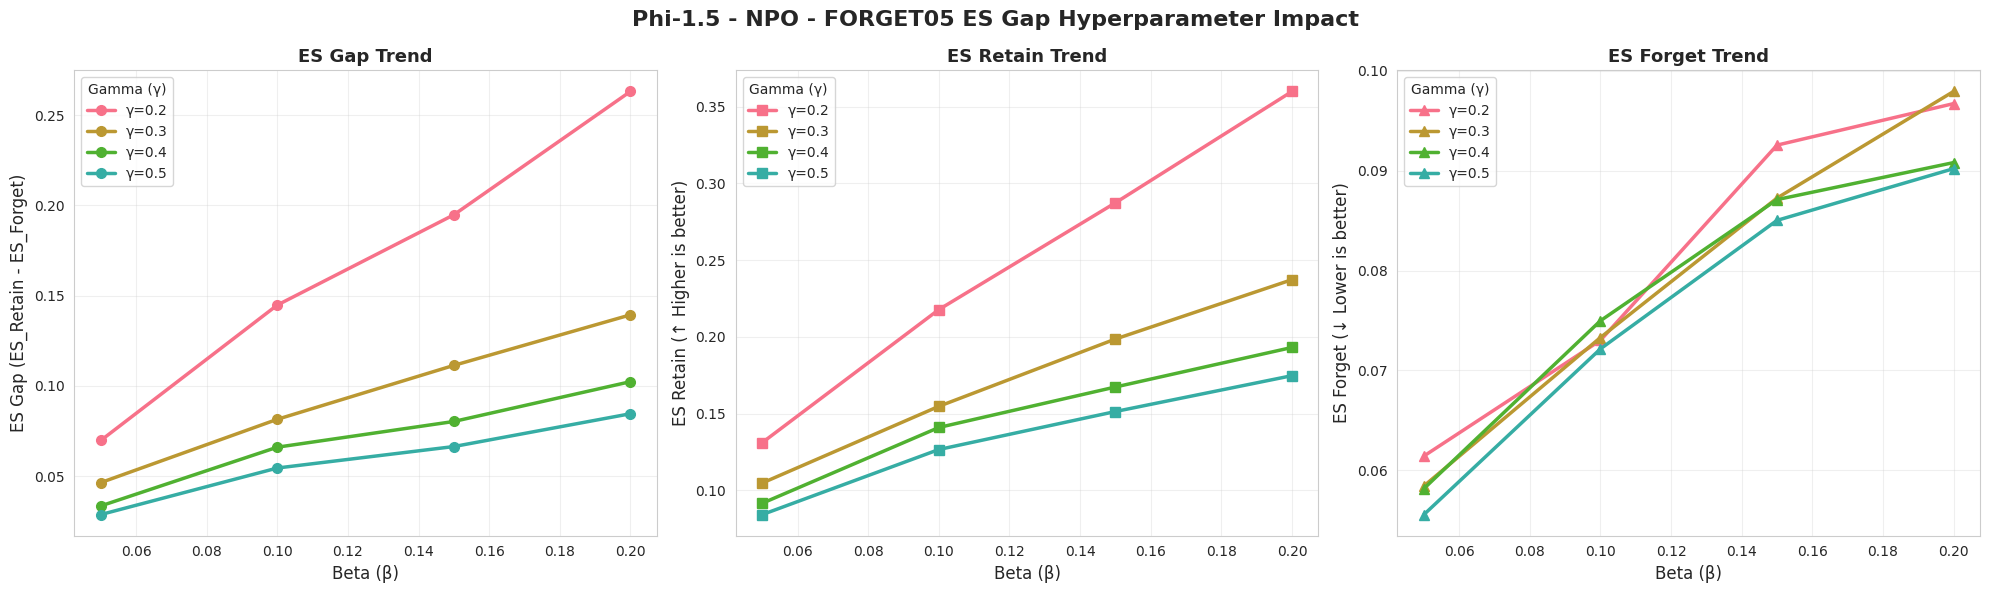

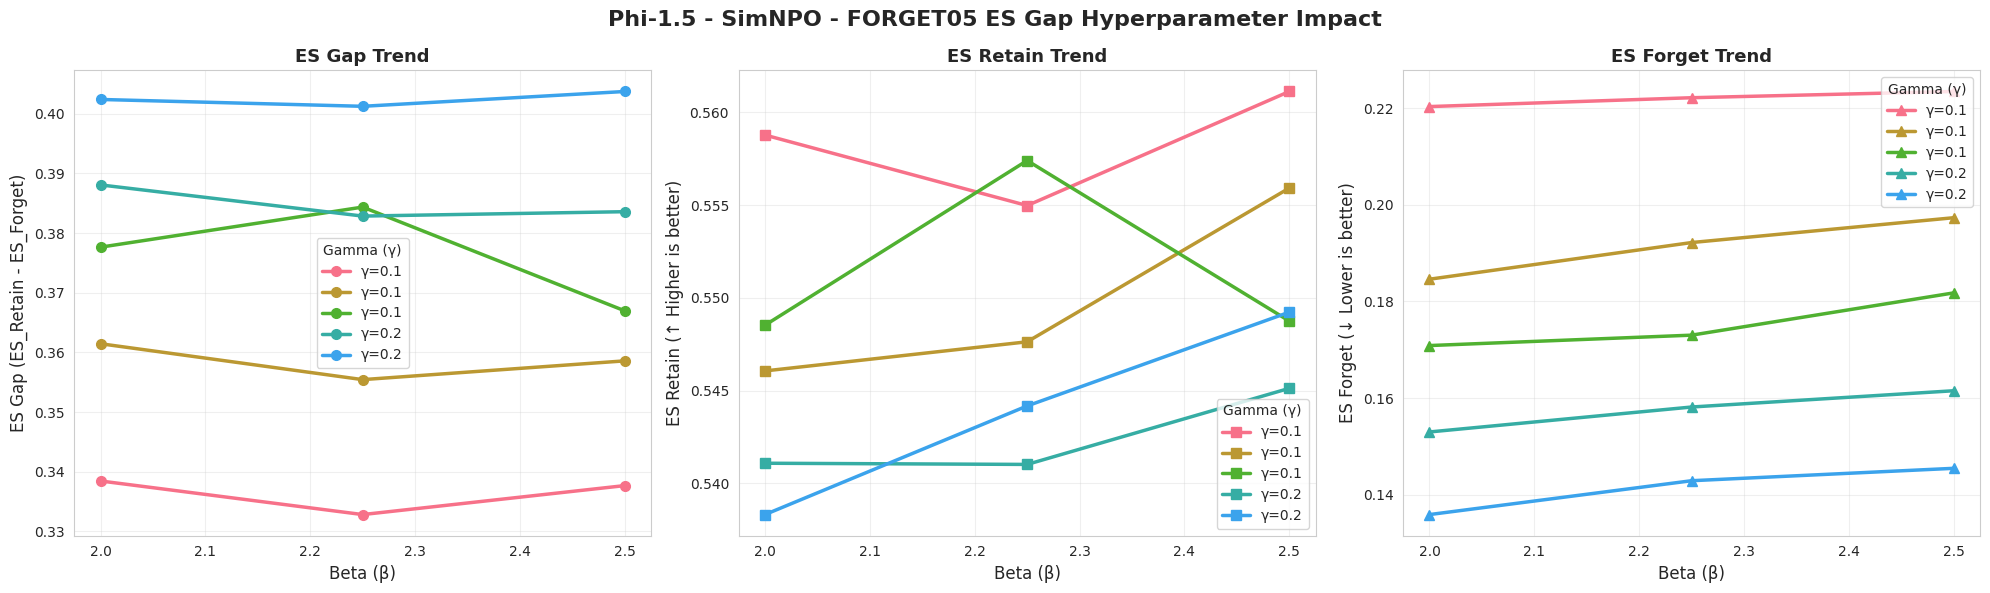

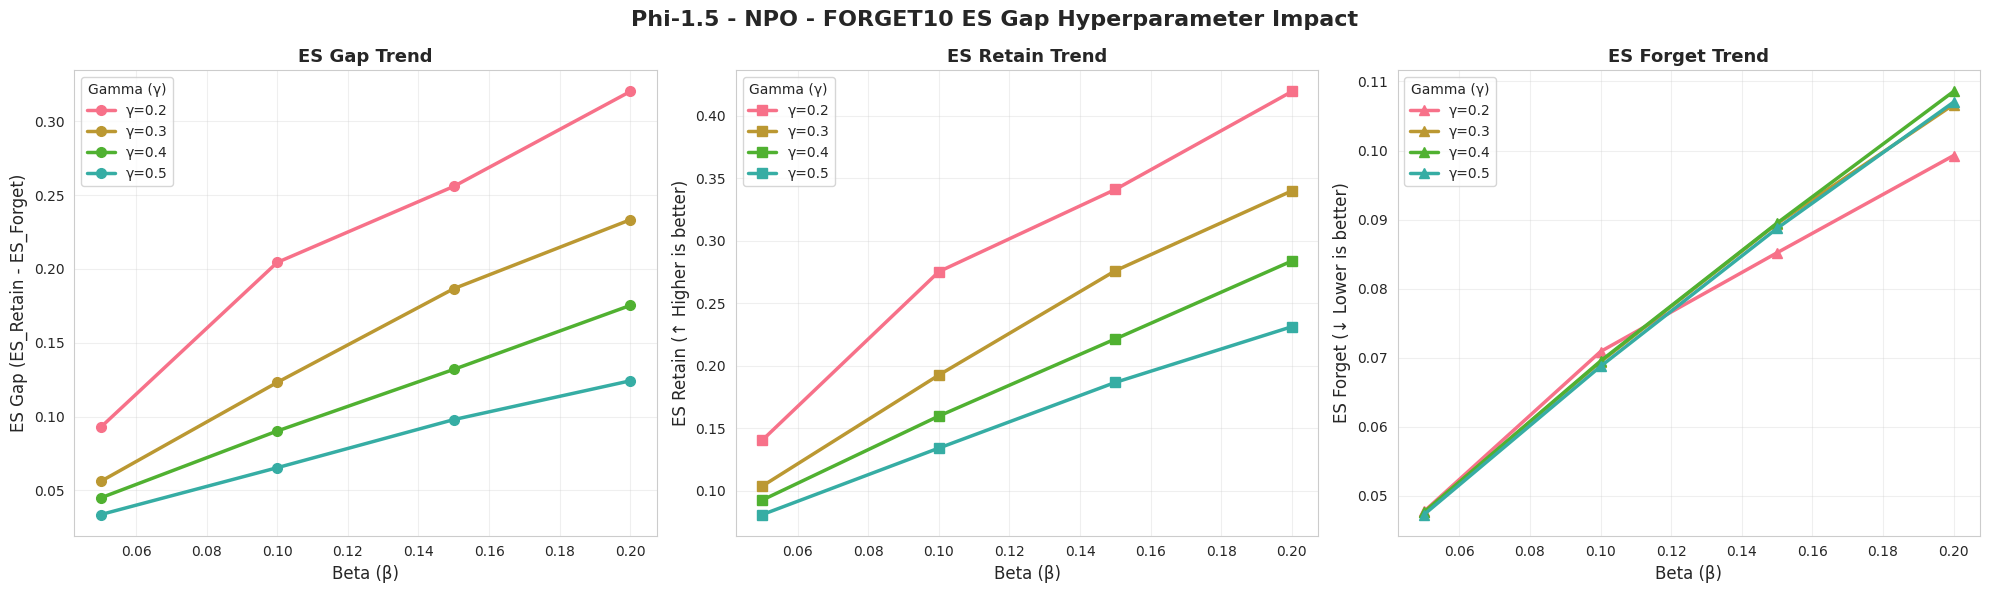

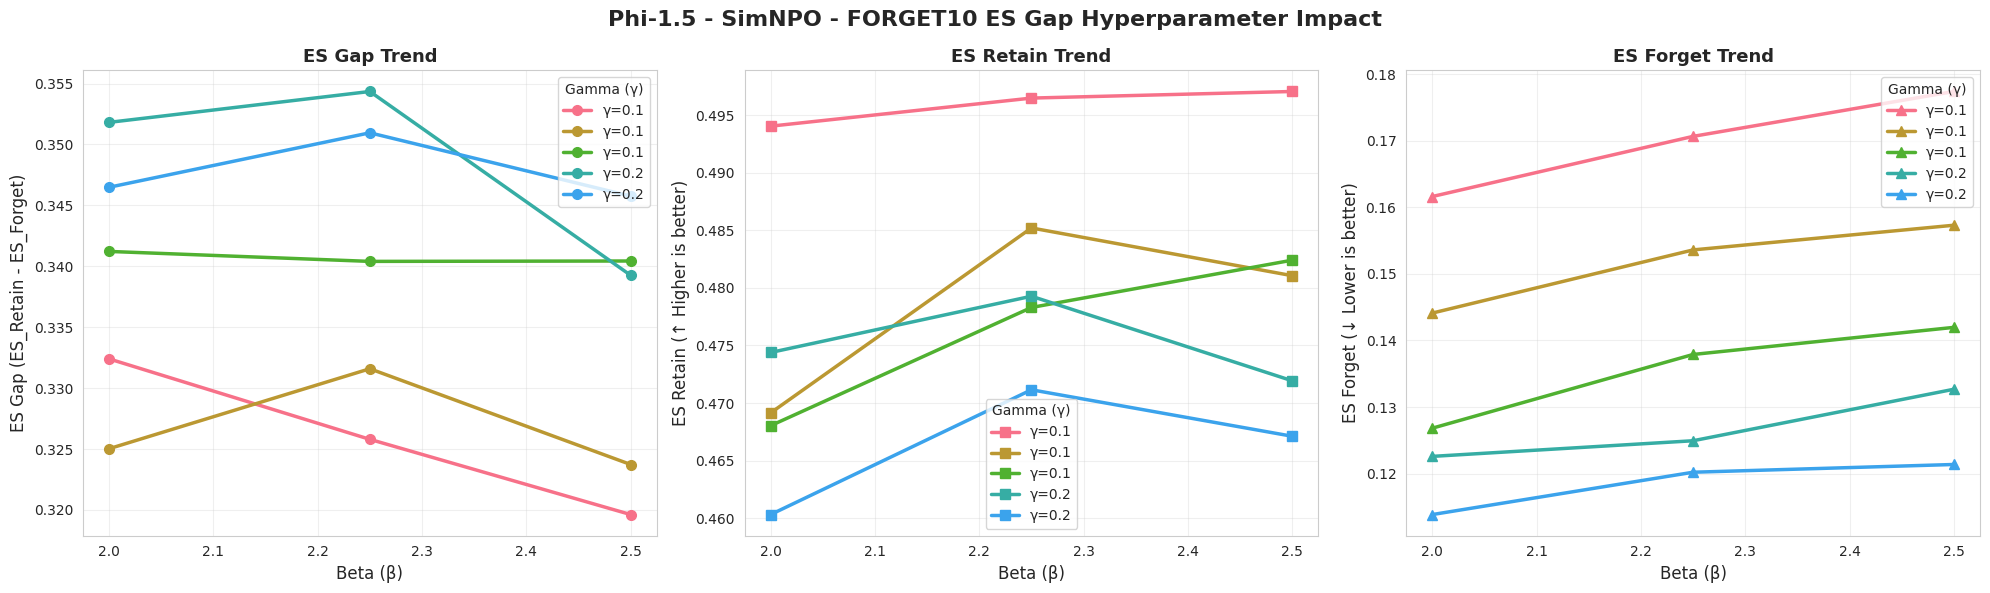

In [19]:
# Analyze ES Gap hyperparameter impact for each method and forget set
for forget_set in forget_sets:
    for method in methods:
        method_df = df[(df['method'] == method) & (df['forget_set'] == forget_set)].copy()
        
        if len(method_df) < 2:
            continue
        
        # Check if beta and gamma exist
        has_beta = 'beta' in method_df.columns and method_df['beta'].notna().any()
        has_gamma = 'gamma' in method_df.columns and method_df['gamma'].notna().any()
        
        if not (has_beta or has_gamma):
            continue
        
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        fig.suptitle(f'{model_name} - {method} - {forget_set.upper()} ES Gap Hyperparameter Impact', 
                     fontsize=16, fontweight='bold')
        
        # Plot 1: ES Gap vs hyperparameter
        ax1 = axes[0]
        if has_beta and has_gamma:
            # Group by gamma and plot lines for different gamma values
            for gamma_val in sorted(method_df['gamma'].unique()):
                gamma_df = method_df[method_df['gamma'] == gamma_val].sort_values('beta')
                if len(gamma_df) > 0:
                    ax1.plot(gamma_df['beta'], gamma_df['es_gap'], 
                           marker='o', label=f'γ={gamma_val:.1f}', linewidth=2.5, markersize=7)
            ax1.set_xlabel('Beta (β)', fontsize=12)
            ax1.legend(loc='best', fontsize=10, title='Gamma (γ)')
        elif has_beta:
            method_df_sorted = method_df.sort_values('beta')
            ax1.plot(method_df_sorted['beta'], method_df_sorted['es_gap'], 
                   marker='o', linewidth=2.5, markersize=8, color='#2E86AB')
            ax1.set_xlabel('Beta (β)', fontsize=12)
        elif has_gamma:
            method_df_sorted = method_df.sort_values('gamma')
            ax1.plot(method_df_sorted['gamma'], method_df_sorted['es_gap'], 
                   marker='o', linewidth=2.5, markersize=8, color='#2E86AB')
            ax1.set_xlabel('Gamma (γ)', fontsize=12)
        
        ax1.set_ylabel('ES Gap (ES_Retain - ES_Forget)', fontsize=12)
        ax1.set_title('ES Gap Trend', fontsize=13, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: ES Retain vs hyperparameter
        ax2 = axes[1]
        if has_beta and has_gamma:
            for gamma_val in sorted(method_df['gamma'].unique()):
                gamma_df = method_df[method_df['gamma'] == gamma_val].sort_values('beta')
                if len(gamma_df) > 0:
                    ax2.plot(gamma_df['beta'], gamma_df['extraction_strength_retain'], 
                           marker='s', label=f'γ={gamma_val:.1f}', linewidth=2.5, markersize=7)
            ax2.set_xlabel('Beta (β)', fontsize=12)
            ax2.legend(loc='best', fontsize=10, title='Gamma (γ)')
        elif has_beta:
            method_df_sorted = method_df.sort_values('beta')
            ax2.plot(method_df_sorted['beta'], method_df_sorted['extraction_strength_retain'], 
                   marker='s', linewidth=2.5, markersize=8, color='#A23B72')
            ax2.set_xlabel('Beta (β)', fontsize=12)
        elif has_gamma:
            method_df_sorted = method_df.sort_values('gamma')
            ax2.plot(method_df_sorted['gamma'], method_df_sorted['extraction_strength_retain'], 
                   marker='s', linewidth=2.5, markersize=8, color='#A23B72')
            ax2.set_xlabel('Gamma (γ)', fontsize=12)
        
        ax2.set_ylabel('ES Retain (↑ Higher is better)', fontsize=12)
        ax2.set_title('ES Retain Trend', fontsize=13, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: ES Forget vs hyperparameter
        ax3 = axes[2]
        if has_beta and has_gamma:
            for gamma_val in sorted(method_df['gamma'].unique()):
                gamma_df = method_df[method_df['gamma'] == gamma_val].sort_values('beta')
                if len(gamma_df) > 0:
                    ax3.plot(gamma_df['beta'], gamma_df['extraction_strength'], 
                           marker='^', label=f'γ={gamma_val:.1f}', linewidth=2.5, markersize=7)
            ax3.set_xlabel('Beta (β)', fontsize=12)
            ax3.legend(loc='best', fontsize=10, title='Gamma (γ)')
        elif has_beta:
            method_df_sorted = method_df.sort_values('beta')
            ax3.plot(method_df_sorted['beta'], method_df_sorted['extraction_strength'], 
                   marker='^', linewidth=2.5, markersize=8, color='#F18F01')
            ax3.set_xlabel('Beta (β)', fontsize=12)
        elif has_gamma:
            method_df_sorted = method_df.sort_values('gamma')
            ax3.plot(method_df_sorted['gamma'], method_df_sorted['extraction_strength'], 
                   marker='^', linewidth=2.5, markersize=8, color='#F18F01')
            ax3.set_xlabel('Gamma (γ)', fontsize=12)
        
        ax3.set_ylabel('ES Forget (↓ Lower is better)', fontsize=12)
        ax3.set_title('ES Forget Trend', fontsize=13, fontweight='bold')
        ax3.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()


## 10. Best Hyperparameters Based on ES Gap (ES_Retain - ES_Forget)

Select best configuration for each method by maximizing the gap between:
- **ES Retain (higher is better)** - extraction strength on retain data
- **ES Forget (lower is better)** - extraction strength on forget data

The larger the gap (ES_Retain - ES_Forget), the better the unlearning effect.